# PawSafe 원자료(Raw Data) EDA

이 노트북은 `해커톤 데이터 정리.zip`에 들어 있는 정제 전 원자료를 파일별로 살펴봅니다.
단순히 결측률만 계산하지 않고 **행의 의미, 자료형, 명시적·의미상 결측치, 중복, 값의 범위,
범주 분포, 시간·공간 범위, 다른 파일과의 결합 가능성**을 확인합니다.

분석 대상은 다음과 같습니다.

1. 서울시 가로수 CSV
2. 서울 건물 Shapefile 압축파일과 건축물대장 CSV
3. 서울 ASOS 시간별 기상 CSV
4. 송파구 보행로·경계 GeoPackage
5. 잠실 IoT 실측 Excel
6. 보도 포장재 코드표와 보도 공사자료 CSV

> 원본 파일은 변경하지 않습니다. 그래프는 실행 환경의 한글 폰트 문제를 피하도록 영어 축·제목을 사용하고,
> 원래 한글 변수명과 상세 해석은 표와 설명에 그대로 남겼습니다.


## Google Colab 실행 방법

1. 이 `.ipynb` 파일을 Google Colab에서 엽니다.
2. **런타임 → 모두 실행**을 누릅니다.
3. 원자료 ZIP이 없으면 파일 선택 창이 열립니다. `해커톤 데이터 정리.zip` 하나를 선택합니다.
4. ZIP은 안전한 상대경로인지 확인한 뒤 `/content/pawsafe_raw_data`에 자동 압축 해제됩니다.

`pandas`, `numpy`, `matplotlib`, `seaborn`, `openpyxl`과 Python 표준 라이브러리만 사용합니다.
`geopandas` 없이도 GeoPackage 메타데이터와 공간 범위를 확인하도록 구성했습니다.
건물 DBF 79만 건을 전수 스캔하므로 Colab에서 해당 셀은 수십 초 정도 걸릴 수 있습니다.


In [1]:
# 0. 공통 환경과 원자료 ZIP 준비
from pathlib import Path
from collections import Counter
import sqlite3
import struct
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

existing_roots = [
    Path("raw_data/해커톤 데이터 정리"),
    Path("/content/pawsafe_raw_data/해커톤 데이터 정리"),
]
RAW_ROOT = next((p for p in existing_roots if p.exists()), None)

if RAW_ROOT is None:
    zip_candidates = [
        Path("upload/해커톤 데이터 정리.zip"),
        Path("해커톤 데이터 정리.zip"),
        Path("/content/해커톤 데이터 정리.zip"),
    ]
    zip_path = next((p for p in zip_candidates if p.exists()), None)
    if zip_path is None and IN_COLAB:
        from google.colab import files
        print("'해커톤 데이터 정리.zip'을 선택해 업로드하세요.")
        uploaded = files.upload()
        zip_path = Path(next(iter(uploaded)))
    if zip_path is None:
        raise FileNotFoundError("해커톤 데이터 정리.zip을 찾지 못했습니다.")

    extract_dir = Path("/content/pawsafe_raw_data" if IN_COLAB else "raw_data")
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        for member in zf.infolist():
            member_path = Path(member.filename)
            if member_path.is_absolute() or ".." in member_path.parts:
                raise ValueError(f"Unsafe ZIP path: {member.filename}")
        zf.extractall(extract_dir)
    RAW_ROOT = next(extract_dir.rglob("street_trees.csv")).parents[1]

print("Raw-data root:", RAW_ROOT.resolve())


Raw-data root: /workspace/scratch/af74457516f7/raw_data/해커톤 데이터 정리


In [2]:
# 파일 경로와 공통 로딩 함수
paths = {
    "street_trees": RAW_ROOT / "가로수/street_trees.csv",
    "buildings_zip": RAW_ROOT / "건물/buildings_seoul.zip",
    "building_register": RAW_ROOT / "건물/building_register.csv",
    "asos_hourly": RAW_ROOT / "기상/asos_hourly.csv",
    "walkways": RAW_ROOT / "보행로_경계/songpa_walkways.gpkg",
    "boundary": RAW_ROOT / "보행로_경계/songpa_boundary.gpkg",
    "iot_excel": RAW_ROOT / "실측검증/jamsil_iot_observations.xlsx",
    "surface_codes": RAW_ROOT / "포장재/SWM_BASIC_CODE.csv",
    "pavement_work": RAW_ROOT / "포장재/SWM_WKAR_AS.csv",
}

def read_csv_auto(path):
    for encoding in ["utf-8-sig", "cp949"]:
        try:
            return pd.read_csv(path, encoding=encoding, low_memory=False), encoding
        except UnicodeDecodeError:
            pass
    raise UnicodeError(f"Encoding not resolved: {path}")

def column_profile(df):
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing_n": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "nunique": df.nunique(dropna=False),
    })

trees_raw, tree_encoding = read_csv_auto(paths["street_trees"])
building_register, building_encoding = read_csv_auto(paths["building_register"])
asos, asos_encoding = read_csv_auto(paths["asos_hourly"])
surface_codes, code_encoding = read_csv_auto(paths["surface_codes"])
pavement, pavement_encoding = read_csv_auto(paths["pavement_work"])

print("CSV encodings")
print({
    "street_trees": tree_encoding,
    "building_register": building_encoding,
    "asos_hourly": asos_encoding,
    "surface_codes": code_encoding,
    "pavement_work": pavement_encoding,
})


CSV encodings
{'street_trees': 'cp949', 'building_register': 'utf-8-sig', 'asos_hourly': 'cp949', 'surface_codes': 'utf-8-sig', 'pavement_work': 'utf-8-sig'}


## 1. 전체 파일 구성

원자료는 표, 공간자료, Excel 실측표가 섞여 있습니다. 같은 방식으로 결측치를 처리하면 안 되며,
각 파일의 관측 단위와 역할을 먼저 구분해야 합니다.


,file,format,observation_unit,rows_or_records,columns_or_measures,size_mb
0,street_trees.csv,CSV,Tree,257236,31,35.80
1,buildings_seoul.zip,Shapefile ZIP,Building polygon,791970,15,96.23
2,building_register.csv,CSV,Building register,1736,77,0.84
3,asos_hourly.csv,CSV,Hourly weather,24,38,0.00
4,songpa_walkways.gpkg,GeoPackage,Walkway line,3767,12,1.12
5,songpa_boundary.gpkg,GeoPackage,Boundary polygon,1,6,0.11
6,jamsil_iot_observations.xlsx,Excel,Temperature observation,2616,4,0.13
7,SWM_BASIC_CODE.csv,CSV,Code dictionary,119,5,0.01
8,SWM_WKAR_AS.csv,CSV,Pavement work,55515,35,9.80


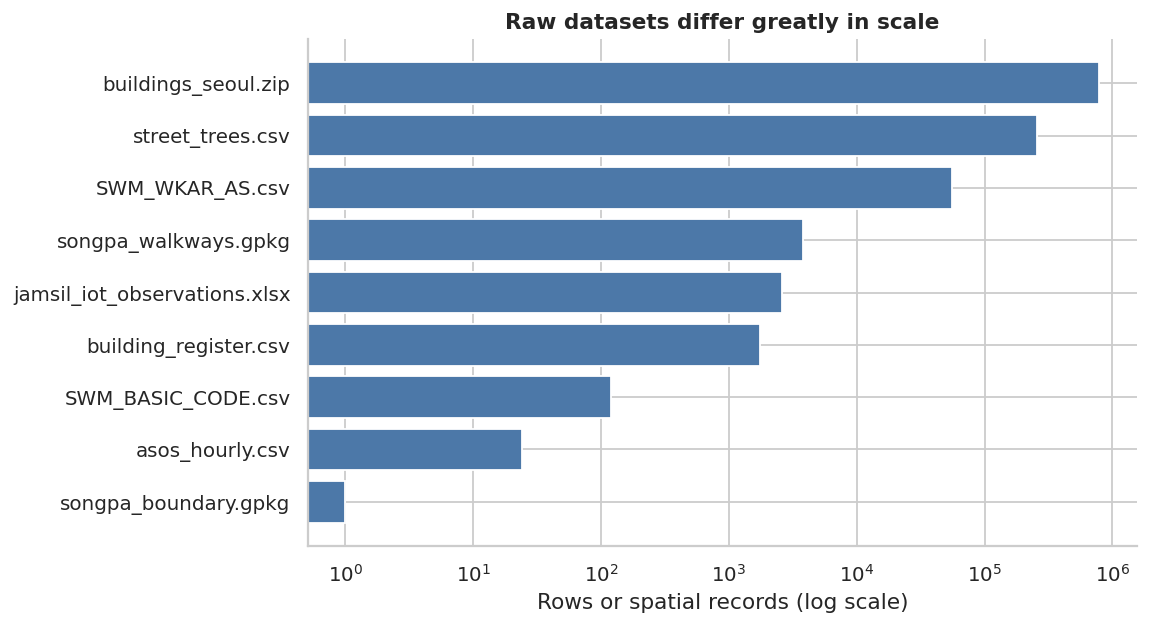

In [3]:
def gpkg_row_count(path):
    with sqlite3.connect(path) as conn:
        table = conn.execute("SELECT table_name FROM gpkg_contents WHERE data_type='features'").fetchone()[0]
        return conn.execute(f'SELECT COUNT(*) FROM "{table}"').fetchone()[0]

def dbf_record_count(zip_path):
    with zipfile.ZipFile(zip_path) as zf:
        member = next(n for n in zf.namelist() if n.lower().endswith(".dbf"))
        with zf.open(member) as fh:
            header = fh.read(32)
    return struct.unpack("<I", header[4:8])[0]

inventory = pd.DataFrame([
    ("street_trees.csv", "CSV", "Tree", len(trees_raw), trees_raw.shape[1], paths["street_trees"].stat().st_size),
    ("buildings_seoul.zip", "Shapefile ZIP", "Building polygon", dbf_record_count(paths["buildings_zip"]), 15, paths["buildings_zip"].stat().st_size),
    ("building_register.csv", "CSV", "Building register", len(building_register), building_register.shape[1], paths["building_register"].stat().st_size),
    ("asos_hourly.csv", "CSV", "Hourly weather", len(asos), asos.shape[1], paths["asos_hourly"].stat().st_size),
    ("songpa_walkways.gpkg", "GeoPackage", "Walkway line", gpkg_row_count(paths["walkways"]), 12, paths["walkways"].stat().st_size),
    ("songpa_boundary.gpkg", "GeoPackage", "Boundary polygon", gpkg_row_count(paths["boundary"]), 6, paths["boundary"].stat().st_size),
    ("jamsil_iot_observations.xlsx", "Excel", "Temperature observation", 8 * 3 * 109, 4, paths["iot_excel"].stat().st_size),
    ("SWM_BASIC_CODE.csv", "CSV", "Code dictionary", len(surface_codes), surface_codes.shape[1], paths["surface_codes"].stat().st_size),
    ("SWM_WKAR_AS.csv", "CSV", "Pavement work", len(pavement), pavement.shape[1], paths["pavement_work"].stat().st_size),
], columns=["file", "format", "observation_unit", "rows_or_records", "columns_or_measures", "bytes"])
inventory["size_mb"] = (inventory["bytes"] / 1024**2).round(2)
display(inventory.drop(columns="bytes"))

fig, ax = plt.subplots(figsize=(9, 5))
order = inventory.sort_values("rows_or_records")
ax.barh(order["file"], order["rows_or_records"], color="#4C78A8")
ax.set_xscale("log")
ax.set_xlabel("Rows or spatial records (log scale)")
ax.set_title("Raw datasets differ greatly in scale")
plt.tight_layout()
plt.show()


건물 Shapefile은 약 79만 건으로 가장 크고, ASOS는 하루 24건뿐입니다. 행 수는 데이터 품질이나
모델 학습 가능성을 뜻하지 않습니다. 예를 들어 공간 객체 79만 개에는 시간 변화가 없고,
ASOS 24행에는 실제 지면온도 시계열이 들어 있습니다.


## 2. 가로수 원자료 — `street_trees.csv`

한 행은 가로수 한 그루를 나타냅니다. 수종·수고·흉고지름·수관너비·관리정보·위경도를 포함합니다.
그늘 계산에서는 위치와 수관 크기가 중요하지만, 원자료 특유의 설명 행과 극단값을 먼저 처리해야 합니다.


In [4]:
# 첫 번째 데이터 행은 값이 아니라 영문 컬럼 설명이다.
display(trees_raw.head(3))
alias_mask = trees_raw["구명"].eq("gu_nm")
print("Embedded English alias rows:", int(alias_mask.sum()))

# 분석용 view만 분리하며 원본 trees_raw는 그대로 둔다.
trees = trees_raw.loc[~alias_mask].copy()
tree_profile = column_profile(trees)
display(tree_profile)
print("Duplicate full rows:", int(trees.duplicated().sum()))


Embedded English alias rows: 1
Duplicate full rows: 0


,구명,고유번호,품계수종,수고,관리등급,위치,환경영향,전정,도로길이,구번호,전선유무,순번,품계활력,흉고지름,품계위치,수관너비,현존유무,관리기관,피해정도,주변토지사용상태,방재,관리방안,수목고유번호,차선수,보호덮개,가로명,가치등급,품계흉고,수목명,경도,위도
0,gu_nm,esntl_no,grd_treeknd,hgt,mng_grd,lc,env_affc,prune,rd_len,gu_no,eltrwr_pa,seq,grd_energy,brhgh_dmr,grd_lc,crwoftr_bdth,now_exst_pa,mng_instt_nm,dmge_stat,cfr_lnd_use_stat,prvn,mng_mth,wdpt_esntl_no,tfcl_cnt,prtc_cover,rd_nm,val_grd,grd_brhgh,wdpt_nm,lnt,lat
1,중구,114,4,10,1,NaN,0,NaN,0,2,1,122,8,25,9,5,0,공원녹지과,0,0,2010. 흡즙성및천공성 해충종합방제,0,2-배오개길-가-0122,0,1,배오개길,0,12,소나무,126.9983663,37.5627216
2,중구,3,6,6,3,약수사거리,0,NaN,0,2,2,35,8,12,6,6,0,공원녹지과,2,0,2010. 진딧물 및 흰불나방 방제,0,2-동호로-가-0035,0,1,동호로,0,3,왕벚나무,127.0118644,37.5544853


,dtype,non_null,missing_n,missing_pct,nunique
구명,object,257235,0,0.00,24
고유번호,object,257235,0,0.00,257235
품계수종,object,254722,2513,0.98,9
수고,object,257235,0,0.00,74
관리등급,object,257235,0,0.00,32
위치,object,188286,68949,26.80,21093
환경영향,object,257235,0,0.00,7
전정,object,65457,191778,74.55,193
도로길이,object,257235,0,0.00,69
구번호,object,255360,1875,0.73,28


두 번째 줄의 `gu_nm`, `hgt`, `lnt`, `lat` 등은 실제 나무가 아니라 영문 변수 설명입니다.
이를 제거하지 않으면 숫자 열이 문자열로 읽히고 통계량이 깨집니다. 완전 중복 행은 없지만,
`고유번호`나 `수목고유번호`의 중복 여부는 별도 키 검증이 필요합니다.


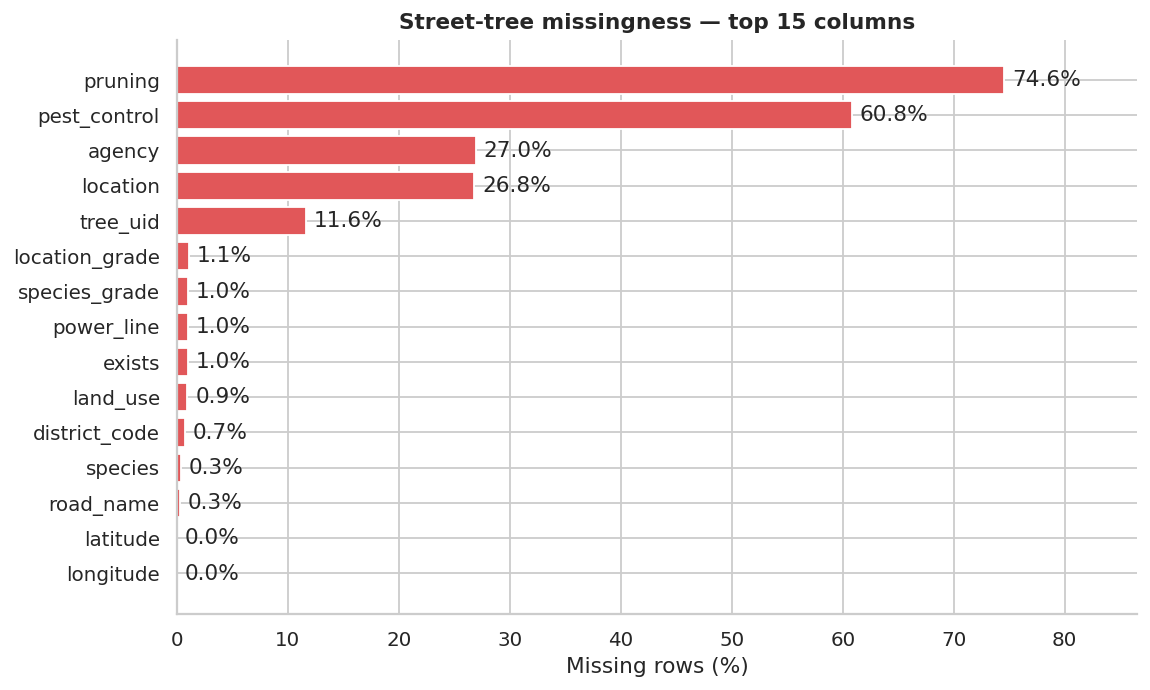

In [5]:
# 명시적 결측치 상위 열
tree_missing_alias = {
    "전정": "pruning", "방재": "pest_control", "관리기관": "agency",
    "위치": "location", "수목고유번호": "tree_uid", "품계위치": "location_grade",
    "품계수종": "species_grade", "전선유무": "power_line", "현존유무": "exists",
    "주변토지사용상태": "land_use", "구번호": "district_code", "수목명": "species",
    "가로명": "road_name", "경도": "longitude", "위도": "latitude",
}
tree_missing = (trees.isna().mean() * 100).sort_values(ascending=False).head(15)
tree_missing_plot = pd.DataFrame({
    "column": [tree_missing_alias.get(c, c) for c in tree_missing.index],
    "missing_pct": tree_missing.values,
}).sort_values("missing_pct")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(tree_missing_plot["column"], tree_missing_plot["missing_pct"], color="#E15759")
ax.set_xlabel("Missing rows (%)")
ax.set_title("Street-tree missingness — top 15 columns")
for i, v in enumerate(tree_missing_plot["missing_pct"]):
    ax.text(v + 0.7, i, f"{v:.1f}%", va="center")
ax.set_xlim(0, max(tree_missing_plot["missing_pct"]) + 12)
plt.tight_layout()
plt.show()


`전정` 74.6%, `방재` 60.8%, `관리기관` 27.0%, `위치` 26.8%가 비어 있습니다.
이 열들은 관리 기록이 없어서 빈 것인지, 실제로 작업을 하지 않았다는 뜻인지 구분해야 합니다.
반면 경도·위도 결측은 약 0.02%로 공간 배치에는 거의 모든 나무를 사용할 수 있습니다.


,count
수목명,
은행나무,109332
양버즘나무,68753
느티나무,22928
버즘나무,17407
벚나무,7195
왕벚나무,6623
메타세쿼이아,5289
회화나무,4655
소나무,2740


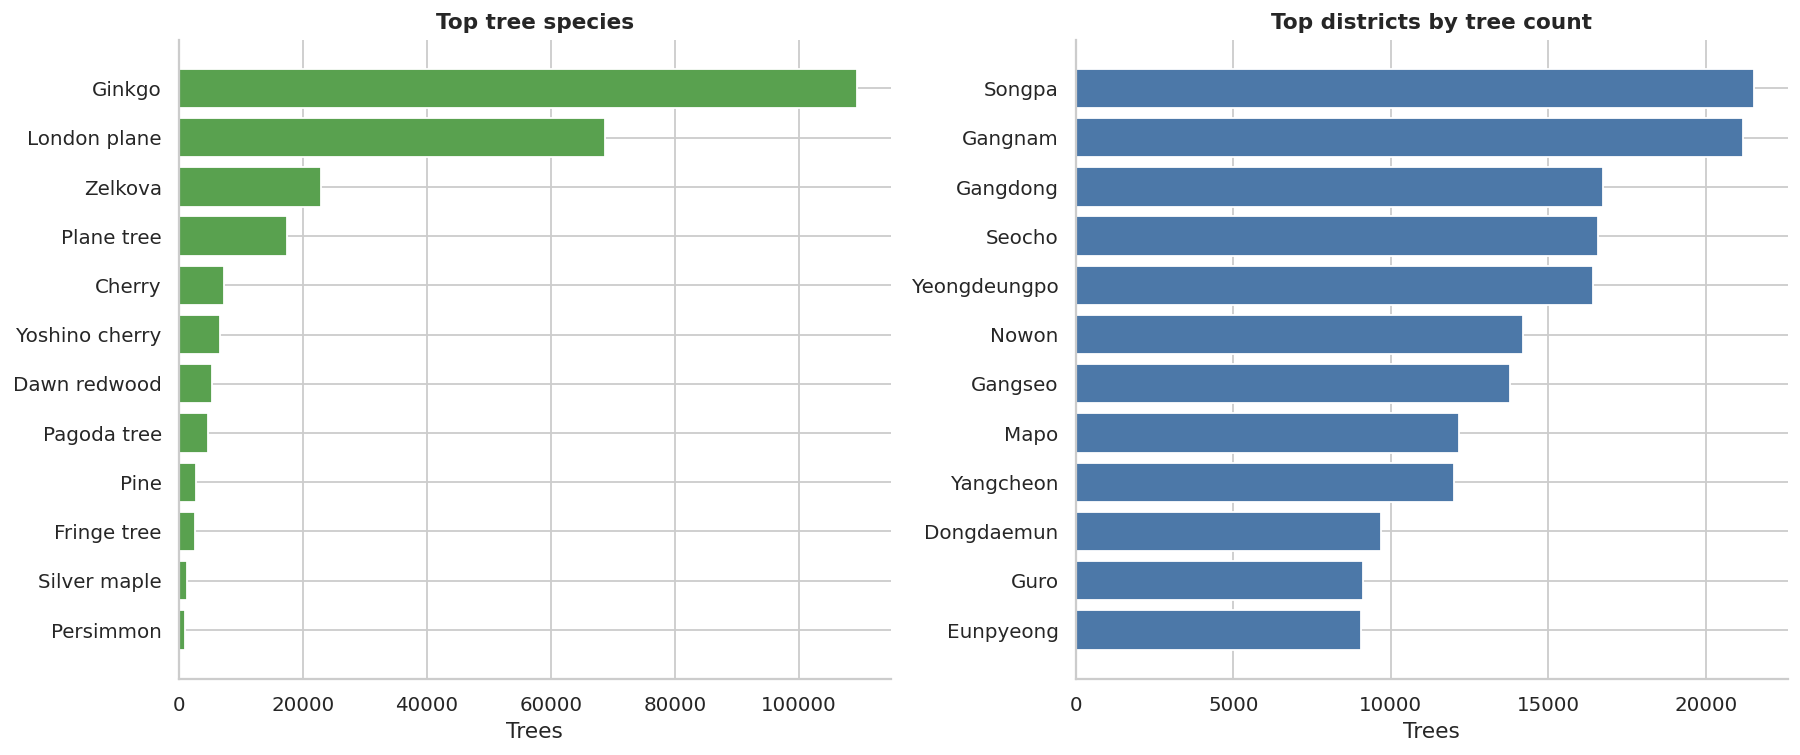

In [6]:
# 수종과 자치구 분포
species_map = {
    "은행나무": "Ginkgo", "양버즘나무": "London plane", "느티나무": "Zelkova",
    "버즘나무": "Plane tree", "벚나무": "Cherry", "왕벚나무": "Yoshino cherry",
    "메타세쿼이아": "Dawn redwood", "회화나무": "Pagoda tree", "소나무": "Pine",
    "이팝나무": "Fringe tree", "은단풍": "Silver maple", "감나무": "Persimmon",
}
district_map = {
    "송파구": "Songpa", "강남구": "Gangnam", "강동구": "Gangdong", "서초구": "Seocho",
    "영등포구": "Yeongdeungpo", "노원구": "Nowon", "강서구": "Gangseo", "마포구": "Mapo",
    "양천구": "Yangcheon", "동대문구": "Dongdaemun", "구로구": "Guro", "은평구": "Eunpyeong",
}
species = trees["수목명"].value_counts().head(12).sort_values()
districts = trees["구명"].value_counts().head(12).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh([species_map.get(x, x) for x in species.index], species.values, color="#59A14F")
axes[0].set_title("Top tree species")
axes[0].set_xlabel("Trees")
axes[1].barh([district_map.get(x, x) for x in districts.index], districts.values, color="#4C78A8")
axes[1].set_title("Top districts by tree count")
axes[1].set_xlabel("Trees")
plt.tight_layout()
plt.show()

display(trees["수목명"].value_counts(dropna=False).head(20).rename("count").to_frame())


은행나무와 양버즘나무가 큰 비중을 차지합니다. `메타세쿼이아`와 `메타세콰이어`처럼 표기 변형도 있어
수종별 수관 특성을 붙이기 전에 명칭 표준화가 필요합니다. 송파구는 21,515그루로 가장 많아
현재 송파 보행로 범위와 연결할 잠재력이 있지만, 단순 자치구명만으로는 각 보행로와의 거리를 알 수 없습니다.


,variable,zero_pct,max
0,height,1.40,1911.0
1,dbh,3.42,2326.0
2,crown_width,1.62,70.0
3,road_length,86.60,16500.0
4,lane_count,100.00,0.0


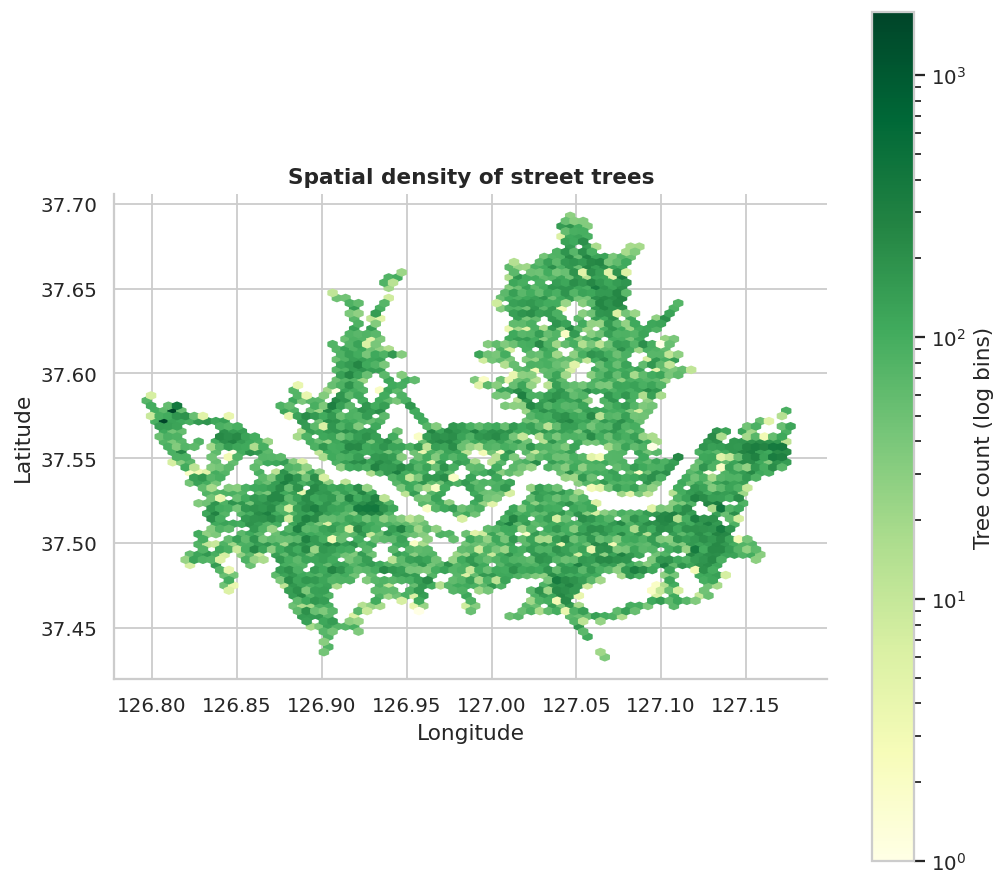

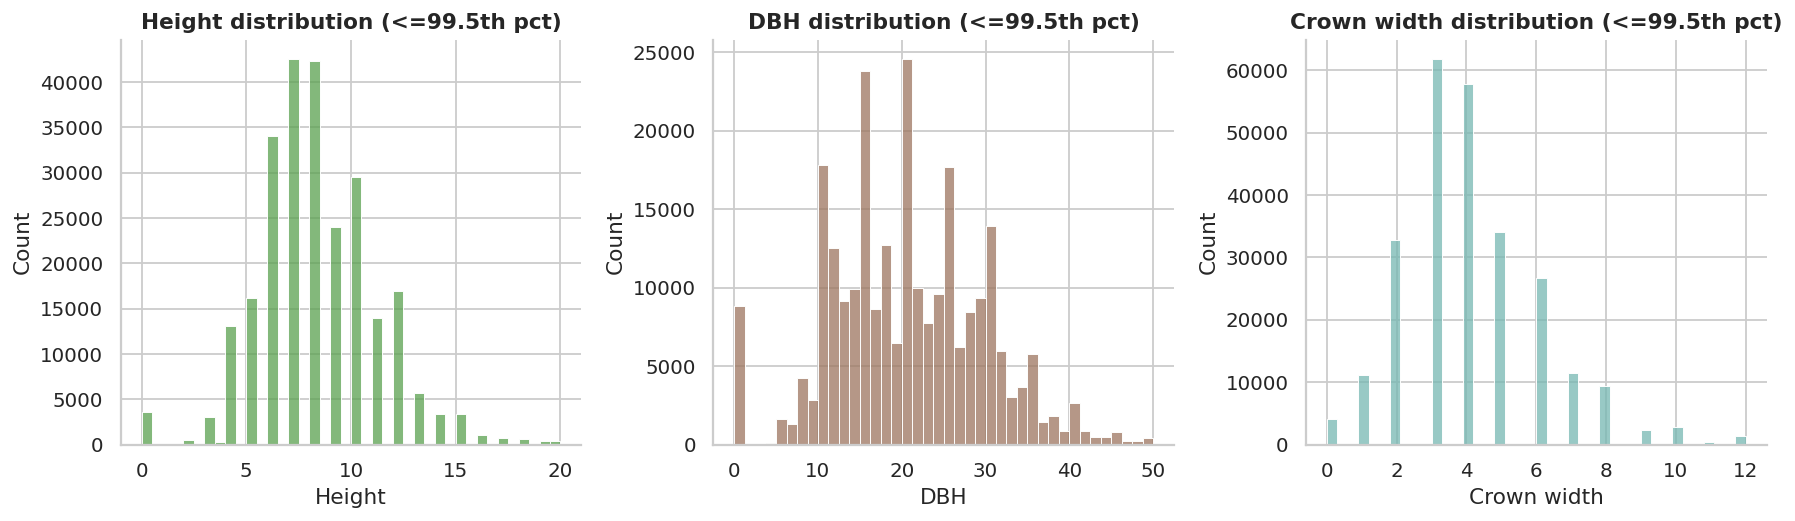

In [7]:
# 공간 분포와 주요 수치형 변수
for col in ["경도", "위도", "수고", "흉고지름", "수관너비", "도로길이", "차선수"]:
    trees[col] = pd.to_numeric(trees[col], errors="coerce")

valid_xy = trees["경도"].between(126, 128) & trees["위도"].between(37, 38)
fig, ax = plt.subplots(figsize=(8, 7))
hb = ax.hexbin(trees.loc[valid_xy, "경도"], trees.loc[valid_xy, "위도"],
               gridsize=75, bins="log", cmap="YlGn", mincnt=1)
fig.colorbar(hb, ax=ax, label="Tree count (log bins)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Spatial density of street trees")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

tree_quality = pd.DataFrame({
    "variable": ["height", "dbh", "crown_width", "road_length", "lane_count"],
    "zero_pct": [trees[c].eq(0).mean() * 100 for c in ["수고", "흉고지름", "수관너비", "도로길이", "차선수"]],
    "max": [trees[c].max() for c in ["수고", "흉고지름", "수관너비", "도로길이", "차선수"]],
})
display(tree_quality.round(2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, col, label, color in zip(
    axes, ["수고", "흉고지름", "수관너비"],
    ["Height", "DBH", "Crown width"], ["#59A14F", "#9C755F", "#76B7B2"]
):
    upper = trees[col].quantile(0.995)
    sns.histplot(trees.loc[trees[col].between(0, upper), col], bins=40, color=color, ax=ax)
    ax.set_title(f"{label} distribution (<=99.5th pct)")
    ax.set_xlabel(label)
plt.tight_layout()
plt.show()


좌표는 99.98% 유효하지만 수치형 값에는 명백한 품질 문제가 있습니다. 수고 최댓값 1,911,
흉고지름 최댓값 2,326은 단위 혼입이나 입력 오류 가능성이 큽니다. 수고 0은 1.4%, 흉고지름 0은 3.4%이며
`차선수`는 전 행이 0이라 현재 feature로 쓸 수 없습니다. `도로길이`도 86.6%가 0입니다.
따라서 0을 실제 0으로 볼지 미측정값으로 볼지 데이터 정의를 확인해야 합니다.


## 3. 건물 공간자료 — `buildings_seoul.zip`

ZIP 안에는 서울 전역 건물 Polygon Shapefile이 있습니다. 전체 DBF를 메모리에 올리지 않고 스트리밍하여
79만 건의 결측치와 층수·종류 코드를 확인합니다.


In [8]:
def read_dbf_header(zip_path):
    with zipfile.ZipFile(zip_path) as zf:
        dbf_member = next(n for n in zf.namelist() if n.lower().endswith(".dbf"))
        with zf.open(dbf_member) as fh:
            header = fh.read(32)
            record_count = struct.unpack("<I", header[4:8])[0]
            header_length = struct.unpack("<H", header[8:10])[0]
            record_length = struct.unpack("<H", header[10:12])[0]
            descriptors = fh.read(header_length - 33)
    fields = []
    for offset in range(0, len(descriptors), 32):
        desc = descriptors[offset:offset + 32]
        if not desc or desc[0] == 0x0D:
            break
        fields.append({
            "name": desc[:11].split(b"\x00", 1)[0].decode("ascii", errors="replace"),
            "type": chr(desc[11]), "length": desc[16], "decimals": desc[17],
        })
    return dbf_member, record_count, header_length, record_length, fields

def scan_building_zip(zip_path):
    member, record_count, header_length, record_length, fields = read_dbf_header(zip_path)
    blank = Counter()
    cats = {name: Counter() for name in ["KIND", "SERV", "SCLS", "NMLY"]}
    active = 0
    deleted = 0
    with zipfile.ZipFile(zip_path) as zf:
        with zf.open(member) as fh:
            fh.read(header_length)
            for _ in range(record_count):
                rec = fh.read(record_length)
                if len(rec) < record_length:
                    break
                if rec[:1] == b"*":
                    deleted += 1
                    continue
                active += 1
                pos = 1
                for field in fields:
                    raw = rec[pos:pos + field["length"]]
                    pos += field["length"]
                    value = raw.decode("cp949", errors="replace").replace("\x00", "").strip()
                    if value == "":
                        blank[field["name"]] += 1
                    if field["name"] in cats:
                        cats[field["name"]][value or "<blank>"] += 1

        shp_member = next(n for n in zf.namelist() if n.lower().endswith(".shp"))
        prj_member = next(n for n in zf.namelist() if n.lower().endswith(".prj"))
        with zf.open(shp_member) as fh:
            shp_header = fh.read(100)
        with zf.open(prj_member) as fh:
            prj_text = fh.read().decode("utf-8", errors="replace")

    return {
        "active": active, "deleted": deleted, "fields": fields,
        "blank_pct": {f["name"]: blank[f["name"]] / active * 100 for f in fields},
        "categorical": cats,
        "shape_type": struct.unpack("<i", shp_header[32:36])[0],
        "bbox": struct.unpack("<4d", shp_header[36:68]),
        "crs": "EPSG:5179" if "Unified_Coordinate_System" in prj_text else prj_text[:100],
    }

print("Scanning 791,970 DBF records...")
building_scan = scan_building_zip(paths["buildings_zip"])
print("Completed.")
display(pd.DataFrame(building_scan["fields"]))
print({k: building_scan[k] for k in ["active", "deleted", "shape_type", "bbox", "crs"]})


Scanning 791,970 DBF records...
Completed.
{'active': 791970, 'deleted': 0, 'shape_type': 5, 'bbox': (935115.3651, 1936876.8395000007, 972005.1867000002, 1966854.237400001), 'crs': 'EPSG:5179'}


,name,type,length,decimals
0,UFID,C,34,0
1,BJCD,C,10,0
2,NAME,C,254,0
3,DIVI,C,20,0
4,KIND,C,6,0
5,SERV,C,6,0
6,ANNO,C,254,0
7,NMLY,N,5,0
8,RDNM,C,50,0
9,BONU,N,10,0


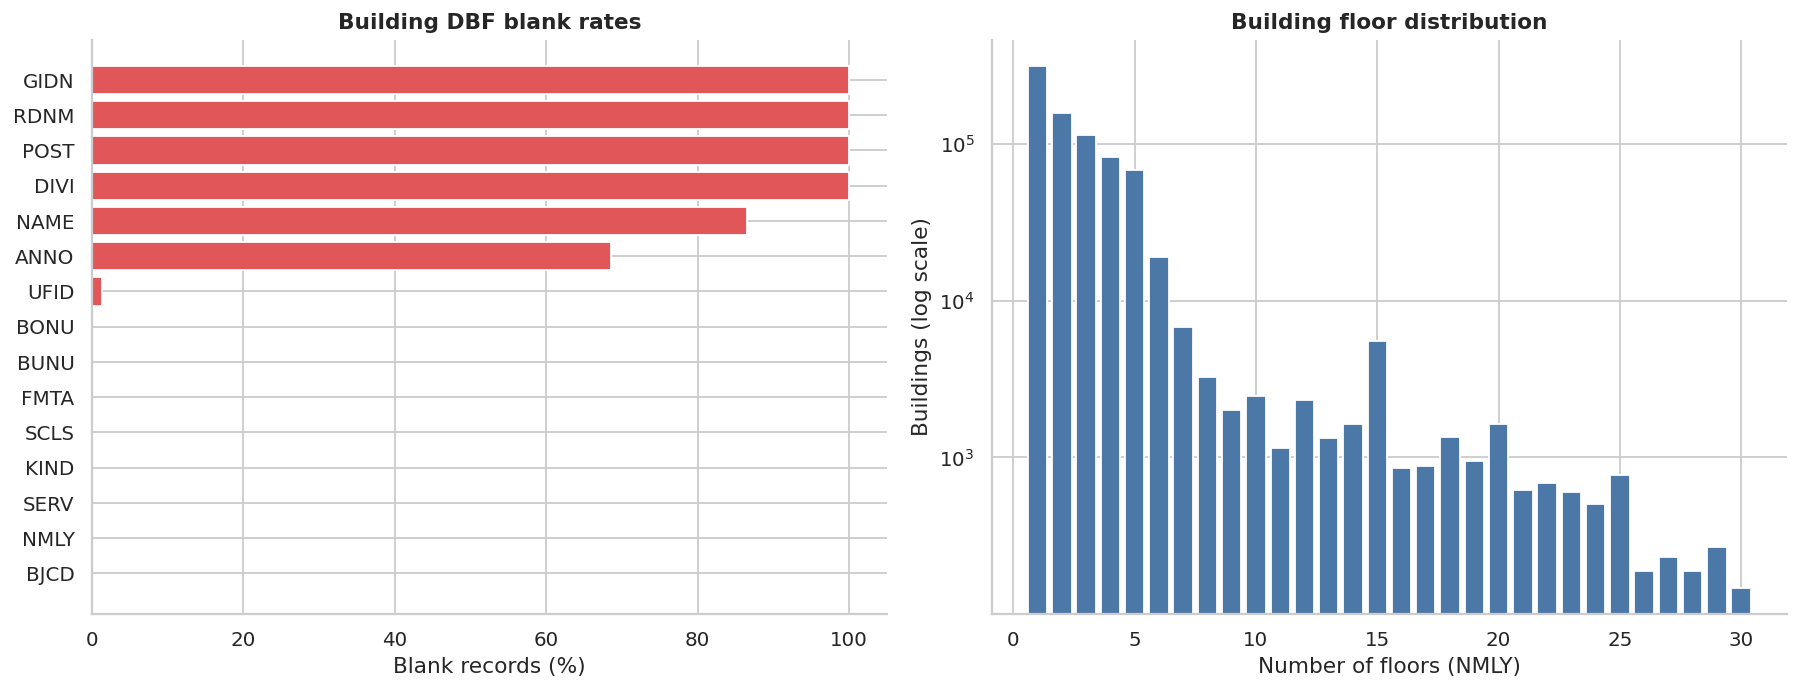

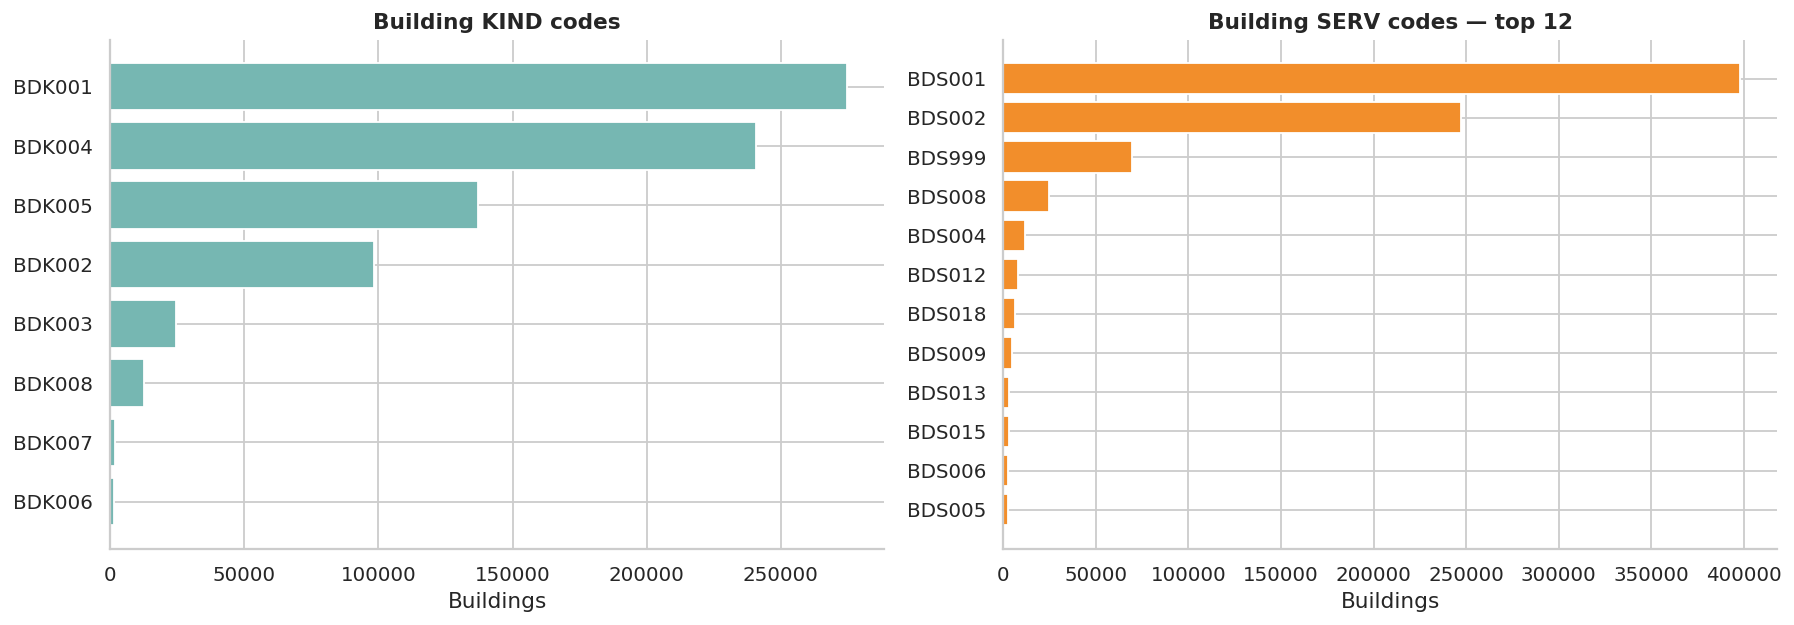

In [9]:
shp_missing = pd.Series(building_scan["blank_pct"]).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].barh(shp_missing.index, shp_missing.values, color="#E15759")
axes[0].set_xlabel("Blank records (%)")
axes[0].set_title("Building DBF blank rates")

floor_counts = pd.Series(building_scan["categorical"]["NMLY"]).drop(labels="<blank>", errors="ignore")
floor_index = pd.to_numeric(floor_counts.index, errors="coerce")
floors = pd.DataFrame({"floor": floor_index, "count": floor_counts.values}).dropna().sort_values("floor")
floors = floors[floors["floor"] <= 30]
axes[1].bar(floors["floor"], floors["count"], color="#4C78A8")
axes[1].set_yscale("log")
axes[1].set_xlabel("Number of floors (NMLY)")
axes[1].set_ylabel("Buildings (log scale)")
axes[1].set_title("Building floor distribution")
plt.tight_layout()
plt.show()

kind = pd.Series(building_scan["categorical"]["KIND"]).sort_values().tail(8)
serv = pd.Series(building_scan["categorical"]["SERV"]).sort_values().tail(12)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(kind.index, kind.values, color="#76B7B2")
axes[0].set_title("Building KIND codes")
axes[0].set_xlabel("Buildings")
axes[1].barh(serv.index, serv.values, color="#F28E2B")
axes[1].set_title("Building SERV codes — top 12")
axes[1].set_xlabel("Buildings")
plt.tight_layout()
plt.show()


Shapefile에는 791,970개 건물 Polygon이 있고 삭제 레코드는 없습니다. 좌표계는 **EPSG:5179**입니다.
`DIVI`, `RDNM`, `POST`, `GIDN`은 전부 비어 있고, `NAME`은 86.5%, `ANNO`는 68.6%가 비어 있습니다.
반면 `NMLY` 층수는 결측이 없고 1~5층이 대부분입니다. `KIND`, `SERV`는 코드만 있으므로
코드북 없이 의미를 임의로 해석하면 안 됩니다. 건물 높이보다 층수를 그늘 높이 proxy로 쓰려면
층고 가정과 검증이 필요합니다.


## 4. 건축물대장 — `building_register.csv`

한 행은 건축물대장 표제부입니다. 건물 높이·층수·면적·구조·용도·승인일 등이 있어
Shapefile의 단순 층수보다 풍부하지만, 전체 서울 건물 수에 비해 1,736행뿐입니다.


In [10]:
display(building_register[[
    "대지위치", "관리건축물대장PK", "주용도코드명", "구조코드명",
    "대지면적(㎡)", "건축면적(㎡)", "연면적(㎡)", "높이(m)", "지상층수", "사용승인일"
]].head(5))
breg_profile = column_profile(building_register)
display(breg_profile)
print("Duplicate full rows:", int(building_register.duplicated().sum()))
print("Unique district/legal-dong codes:",
      building_register[["시군구코드", "법정동코드"]].drop_duplicates().to_dict("records"))


Duplicate full rows: 0
Unique district/legal-dong codes: [{'시군구코드': 11680, '법정동코드': 10300}]


,대지위치,관리건축물대장PK,주용도코드명,구조코드명,대지면적(㎡),건축면적(㎡),연면적(㎡),높이(m),지상층수,사용승인일
0,서울특별시 강남구 개포동 12번지,10241936,공동주택,철근콘크리트구조,0.0,592.93,8969.43,0.0,15,19921014.0
1,서울특별시 강남구 개포동 12번지,10241935,공동주택,철근콘크리트구조,0.0,592.93,8919.27,0.0,15,19921014.0
2,서울특별시 강남구 개포동 12번지,10241921,공동주택,철근콘크리트구조,0.0,417.43,6458.47,0.0,15,19921014.0
3,서울특별시 강남구 개포동 12번지,102417005,노유자시설,철근콘크리트구조,0.0,632.53,2131.66,0.0,3,19911120.0
4,서울특별시 강남구 개포동 12번지,10241931,공동주택,철근콘크리트구조,0.0,346.23,5501.27,0.0,15,19911120.0


,dtype,non_null,missing_n,missing_pct,nunique
대지위치,object,1736,0,0.00,1345
시군구코드,int64,1736,0,0.00,1
법정동코드,int64,1736,0,0.00,1
대지구분코드,int64,1736,0,0.00,1
번,int64,1736,0,0.00,180
지,int64,1736,0,0.00,37
관리건축물대장PK,object,1736,0,0.00,1736
대장구분코드,int64,1736,0,0.00,2
대장구분코드명,object,1736,0,0.00,2
대장종류코드,int64,1736,0,0.00,2


,column,zero_pct,missing_pct,median,max
0,대지면적(㎡),33.06,0.0,213.55,103585.30
1,건축면적(㎡),2.88,0.0,142.44,13610.18
2,연면적(㎡),0.00,0.0,632.42,217901.79
3,높이(m),27.19,0.0,12.70,111.97
4,지상층수,2.25,0.0,5.00,35.00
5,지하층수,31.97,0.0,1.00,6.00


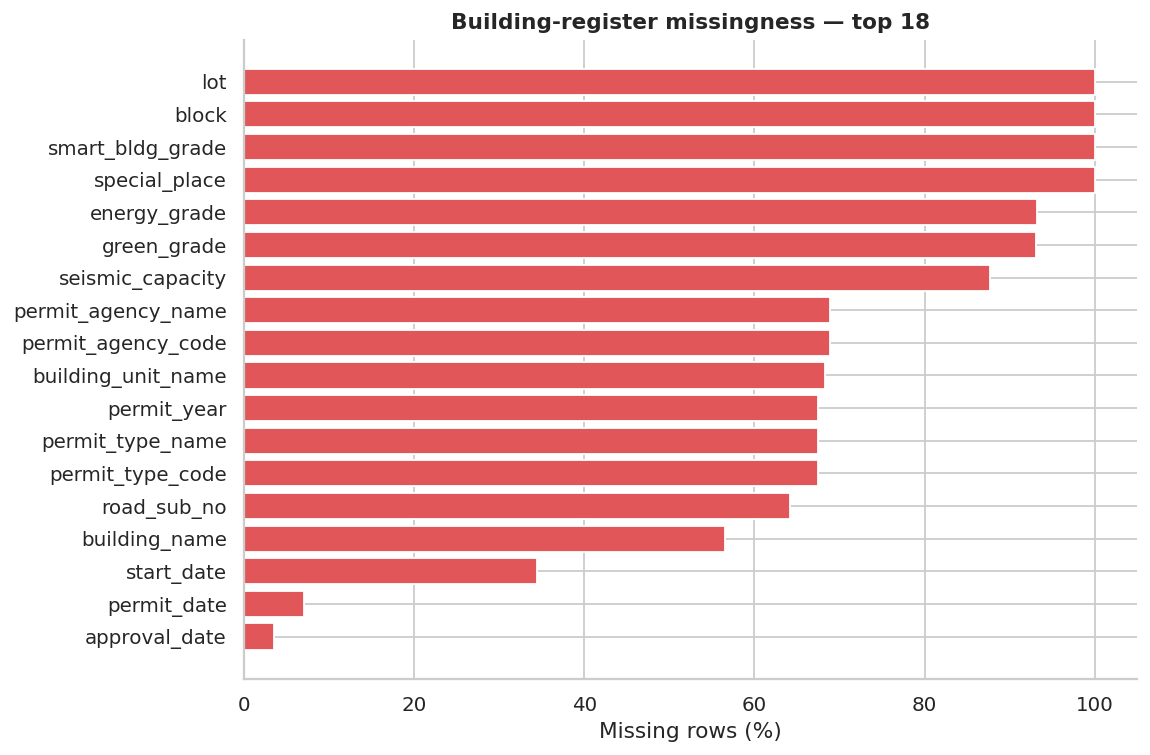

In [11]:
breg_missing_alias = {
    "특수지명": "special_place", "지능형건축물등급": "smart_bldg_grade",
    "로트": "lot", "블록": "block", "에너지효율등급": "energy_grade",
    "친환경건축물등급": "green_grade", "내진능력": "seismic_capacity",
    "허가번호기관코드": "permit_agency_code", "허가번호기관코드명": "permit_agency_name",
    "동명칭": "building_unit_name", "허가번호구분코드": "permit_type_code",
    "허가번호년": "permit_year", "허가번호구분코드명": "permit_type_name",
    "새주소부번": "road_sub_no", "건물명": "building_name", "착공일": "start_date",
    "허가일": "permit_date", "사용승인일": "approval_date",
}
breg_missing = (building_register.isna().mean() * 100).sort_values(ascending=False).head(18)
breg_plot = pd.DataFrame({
    "column": [breg_missing_alias.get(c, c) for c in breg_missing.index],
    "missing_pct": breg_missing.values,
}).sort_values("missing_pct")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(breg_plot["column"], breg_plot["missing_pct"], color="#E15759")
ax.set_xlabel("Missing rows (%)")
ax.set_title("Building-register missingness — top 18")
plt.tight_layout()
plt.show()

numeric_cols = ["대지면적(㎡)", "건축면적(㎡)", "연면적(㎡)", "높이(m)", "지상층수", "지하층수"]
for col in numeric_cols:
    building_register[col] = pd.to_numeric(building_register[col], errors="coerce")
zero_table = pd.DataFrame({
    "column": numeric_cols,
    "zero_pct": [building_register[c].eq(0).mean() * 100 for c in numeric_cols],
    "missing_pct": [building_register[c].isna().mean() * 100 for c in numeric_cols],
    "median": [building_register[c].median() for c in numeric_cols],
    "max": [building_register[c].max() for c in numeric_cols],
})
display(zero_table.round(2))


네 열은 100% 결측이고 에너지·친환경 등급은 약 93%가 비어 있습니다. 수치형 열은 `NaN`이 없어도
0이 의미상 결측일 수 있습니다. 대지면적 33.1%, 높이 27.2%, 지상층수 2.3%가 0입니다.
건물 높이 0을 실제 높이로 학습하면 그늘 길이가 잘못 계산되므로 원자료 정의 확인 후 결측으로 전환해야 합니다.
또한 시군구·법정동 코드가 한 조합뿐이어서 이 CSV는 서울 전체가 아니라 특정 지역 표본입니다.


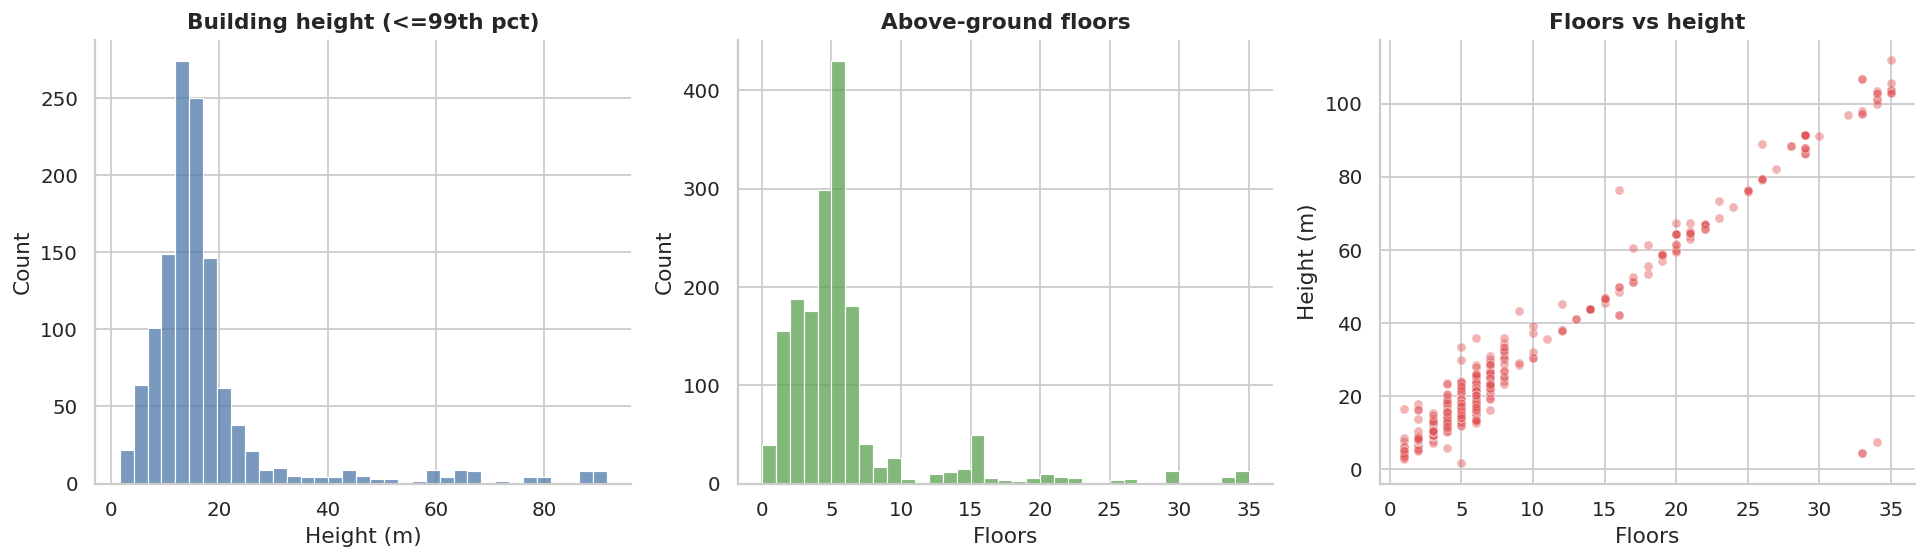

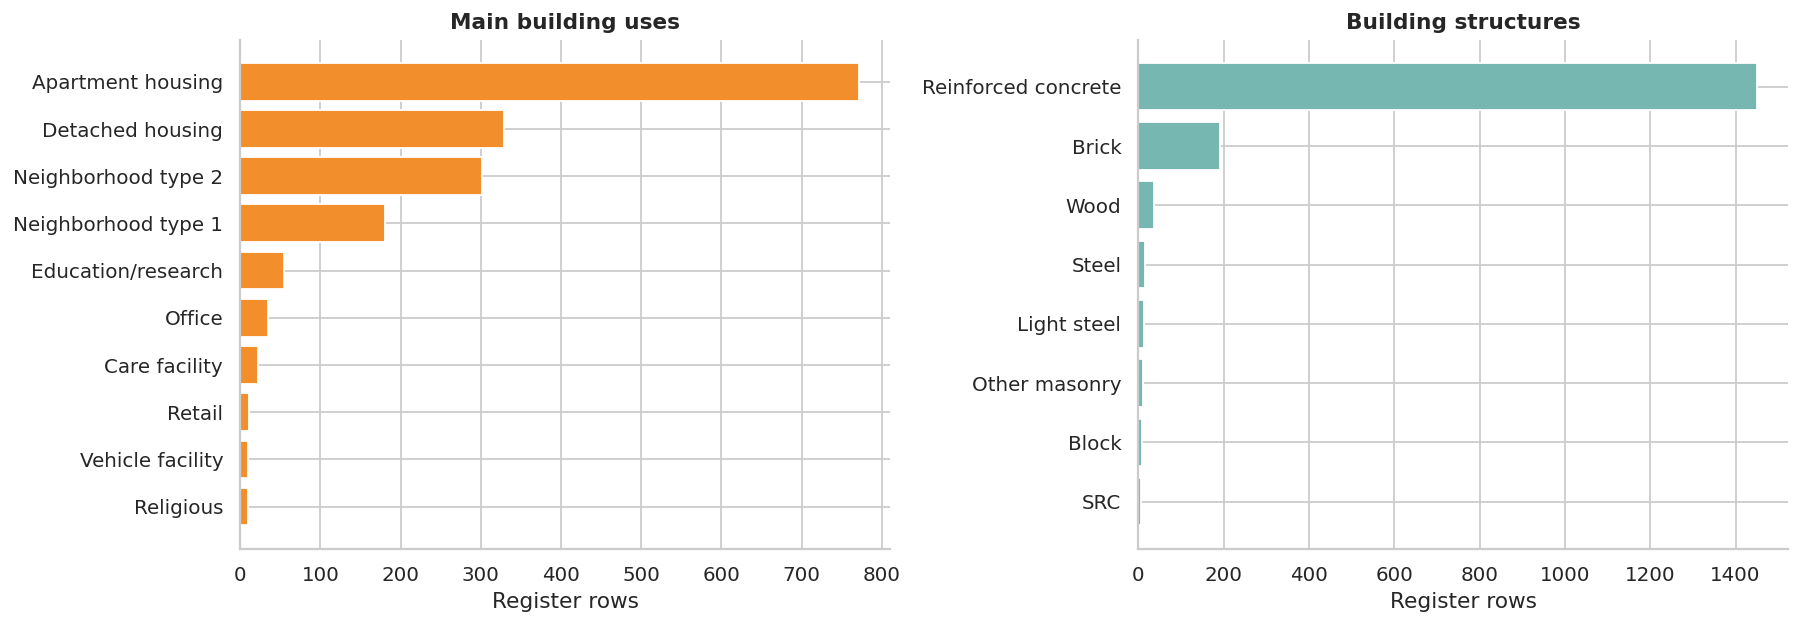

In [12]:
# 건물 수치 분포와 높이-층수 관계
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(building_register.loc[building_register["높이(m)"].between(0.01, building_register["높이(m)"].quantile(.99)), "높이(m)"],
             bins=35, color="#4C78A8", ax=axes[0])
axes[0].set_title("Building height (<=99th pct)")
axes[0].set_xlabel("Height (m)")
sns.histplot(building_register["지상층수"], bins=35, color="#59A14F", ax=axes[1])
axes[1].set_title("Above-ground floors")
axes[1].set_xlabel("Floors")
valid_h = (building_register["높이(m)"] > 0) & (building_register["지상층수"] > 0)
sns.scatterplot(data=building_register.loc[valid_h], x="지상층수", y="높이(m)",
                alpha=.45, s=25, color="#E15759", ax=axes[2])
axes[2].set_title("Floors vs height")
axes[2].set_xlabel("Floors")
axes[2].set_ylabel("Height (m)")
plt.tight_layout()
plt.show()

use_map = {
    "공동주택": "Apartment housing", "단독주택": "Detached housing",
    "제2종근린생활시설": "Neighborhood type 2", "제1종근린생활시설": "Neighborhood type 1",
    "교육연구시설": "Education/research", "업무시설": "Office", "노유자시설": "Care facility",
    "판매시설": "Retail", "자동차관련시설": "Vehicle facility", "종교시설": "Religious",
}
structure_map = {
    "철근콘크리트구조": "Reinforced concrete", "벽돌구조": "Brick", "일반목구조": "Wood",
    "일반철골구조": "Steel", "경량철골구조": "Light steel", "기타조적구조": "Other masonry",
    "블록구조": "Block", "철골철근콘크리트구조": "SRC",
}
uses = building_register["주용도코드명"].value_counts().head(10).sort_values()
structures = building_register["구조코드명"].value_counts().head(8).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([use_map.get(x, x) for x in uses.index], uses.values, color="#F28E2B")
axes[0].set_title("Main building uses")
axes[0].set_xlabel("Register rows")
axes[1].barh([structure_map.get(x, x) for x in structures.index], structures.values, color="#76B7B2")
axes[1].set_title("Building structures")
axes[1].set_xlabel("Register rows")
plt.tight_layout()
plt.show()


높이와 층수는 대체로 함께 증가하지만 같은 층수에서도 높이 편차가 있습니다. 따라서 단순히 `층수 × 3m`로
높이를 만드는 방식은 오차가 생깁니다. 용도는 공동주택, 구조는 철근콘크리트가 크게 우세하여
이 표본에서 얻은 평균 층고를 서울 전체 건물에 적용하기 어렵습니다. Shapefile에는 이 대장의 PK가 없어
두 파일을 바로 일대일 결합할 키도 확인되지 않습니다.


## 5. ASOS 기상·지면온도 — `asos_hourly.csv`

서울 108번 관측소의 2026-08-08 01시부터 8월 9일 00시까지 24시간 자료입니다.
대기 기상뿐 아니라 **지면온도와 5·10·20·30cm 지중온도**가 들어 있어 지도학습 target 후보가 됩니다.


Time range: 2026-08-08 01:00:00 to 2026-08-09 00:00:00
Duplicate timestamps: 0


,지점,지점명,일시,기온(°C),기온 QC플래그,강수량(mm),강수량 QC플래그,풍속(m/s),풍속 QC플래그,풍향(16방위),풍향 QC플래그,습도(%),습도 QC플래그,증기압(hPa),이슬점온도(°C),현지기압(hPa),현지기압 QC플래그,해면기압(hPa),해면기압 QC플래그,일조(hr),일조 QC플래그,일사(MJ/m2),일사 QC플래그,적설(cm),3시간신적설(cm),전운량(10분위),중하층운량(10분위),운형(운형약어),최저운고(100m ),시정(10m),지면상태(지면상태코드),현상번호(국내식),지면온도(°C),지면온도 QC플래그,5cm 지중온도(°C),10cm 지중온도(°C),20cm 지중온도(°C),30cm 지중온도(°C)
0,108,서울,2026-08-08 01:00:00,30.9,NaN,NaN,NaN,1.9,NaN,50,NaN,65,NaN,28.9,23.5,994.7,NaN,1004.2,NaN,NaN,9.0,NaN,9.0,NaN,NaN,0,0,NaN,NaN,2661,NaN,NaN,26.0,NaN,28.7,30.6,30.8,30.3
1,108,서울,2026-08-08 02:00:00,30.7,NaN,NaN,NaN,2.6,NaN,70,NaN,67,NaN,29.5,23.8,994.6,NaN,1004.1,NaN,NaN,9.0,NaN,9.0,NaN,NaN,0,0,NaN,NaN,2509,NaN,NaN,25.8,NaN,28.4,30.3,30.5,30.2
2,108,서울,2026-08-08 03:00:00,30.2,NaN,NaN,NaN,2.9,NaN,50,NaN,66,NaN,28.3,23.1,994.9,NaN,1004.4,NaN,NaN,9.0,NaN,9.0,NaN,NaN,0,0,NaN,NaN,2772,NaN,NaN,25.5,NaN,28.2,30.0,30.3,30.2
3,108,서울,2026-08-08 04:00:00,29.7,NaN,NaN,NaN,2.7,NaN,50,NaN,69,NaN,28.6,23.3,995.6,NaN,1005.2,NaN,NaN,9.0,NaN,9.0,NaN,NaN,1,1,NaN,NaN,2689,NaN,NaN,25.2,NaN,28.0,29.8,30.1,30.1
4,108,서울,2026-08-08 05:00:00,29.6,NaN,NaN,NaN,3.0,NaN,50,NaN,67,NaN,27.7,22.8,996.1,NaN,1005.7,NaN,NaN,9.0,NaN,9.0,NaN,NaN,1,1,NaN,24.0,3071,NaN,NaN,25.2,NaN,27.7,29.6,29.9,30.0


,dtype,non_null,missing_n,missing_pct,nunique
지점,int64,24,0,0.00,1
지점명,object,24,0,0.00,1
일시,datetime64[ns],24,0,0.00,24
기온(°C),float64,24,0,0.00,22
기온 QC플래그,float64,0,24,100.00,1
강수량(mm),float64,0,24,100.00,1
강수량 QC플래그,float64,0,24,100.00,1
풍속(m/s),float64,24,0,0.00,18
풍속 QC플래그,float64,0,24,100.00,1
풍향(16방위),int64,24,0,0.00,3


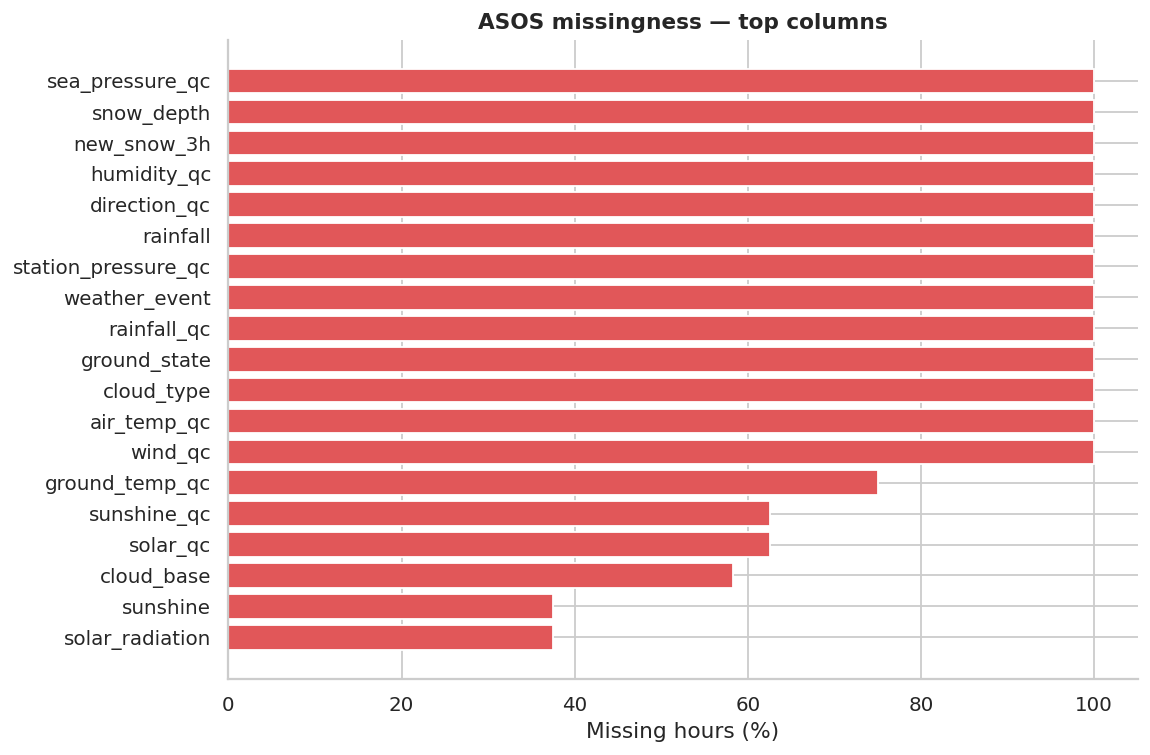

In [13]:
asos["일시"] = pd.to_datetime(asos["일시"], errors="coerce")
display(asos.head(5))
asos_profile = column_profile(asos)
display(asos_profile)
print("Time range:", asos["일시"].min(), "to", asos["일시"].max())
print("Duplicate timestamps:", int(asos["일시"].duplicated().sum()))

asos_missing_alias = {
    "기온 QC플래그": "air_temp_qc", "강수량(mm)": "rainfall", "강수량 QC플래그": "rainfall_qc",
    "풍속 QC플래그": "wind_qc", "풍향 QC플래그": "direction_qc", "습도 QC플래그": "humidity_qc",
    "현지기압 QC플래그": "station_pressure_qc", "해면기압 QC플래그": "sea_pressure_qc",
    "적설(cm)": "snow_depth", "3시간신적설(cm)": "new_snow_3h", "운형(운형약어)": "cloud_type",
    "지면상태(지면상태코드)": "ground_state", "현상번호(국내식)": "weather_event",
    "지면온도 QC플래그": "ground_temp_qc", "일조 QC플래그": "sunshine_qc",
    "일사 QC플래그": "solar_qc", "최저운고(100m )": "cloud_base", "일조(hr)": "sunshine",
    "일사(MJ/m2)": "solar_radiation",
}
asos_missing = (asos.isna().mean() * 100).sort_values(ascending=False).head(19)
asos_plot = pd.DataFrame({
    "column": [asos_missing_alias.get(c, c) for c in asos_missing.index],
    "missing_pct": asos_missing.values,
}).sort_values("missing_pct")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(asos_plot["column"], asos_plot["missing_pct"], color="#E15759")
ax.set_xlabel("Missing hours (%)")
ax.set_title("ASOS missingness — top columns")
plt.tight_layout()
plt.show()


QC 플래그와 강수·적설 관련 열 다수가 전부 비어 있습니다. 강수량 공란은 무강수 관측일 수 있지만
기상청 정의를 확인하기 전에는 통계적 결측과 동일하게 0으로 바꾸지 않습니다. 반면 기온·습도·풍속,
지면온도와 네 깊이의 지중온도는 24시간 모두 존재합니다. 일사·일조 결측 37.5%는 주로 야간이므로
‘측정 실패’와 ‘해당 없음’을 구분해야 합니다.


Pearson correlation: 0.917


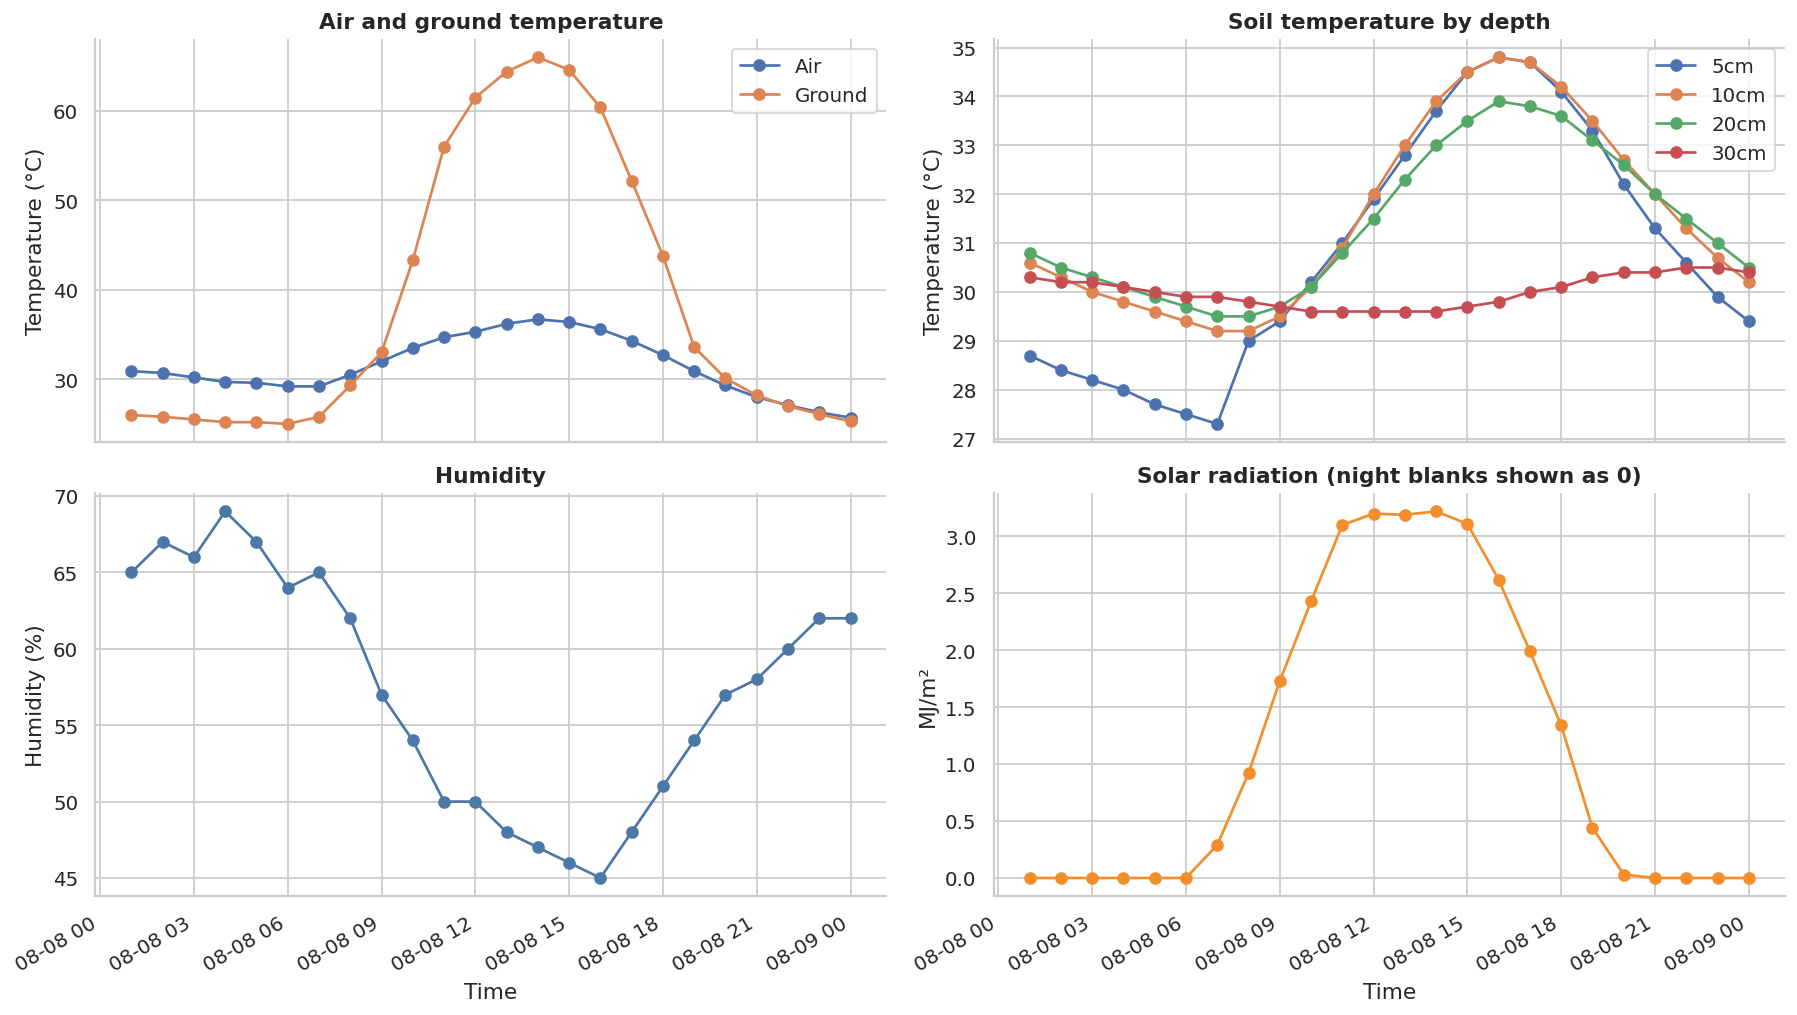

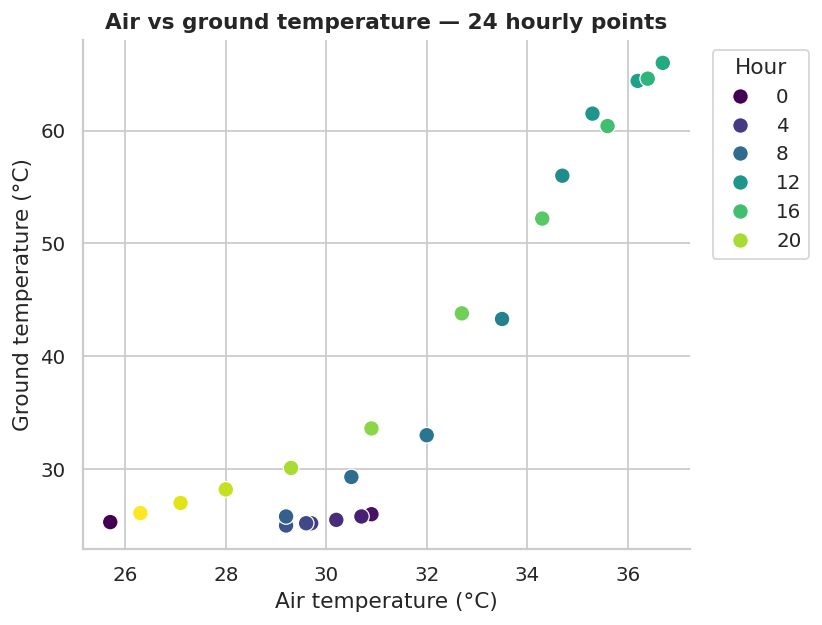

In [14]:
# 시간별 기상·지면/지중온도
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes[0, 0].plot(asos["일시"], asos["기온(°C)"], marker="o", label="Air")
axes[0, 0].plot(asos["일시"], asos["지면온도(°C)"], marker="o", label="Ground")
axes[0, 0].set_title("Air and ground temperature")
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].legend()

soil_cols = ["5cm 지중온도(°C)", "10cm 지중온도(°C)", "20cm 지중온도(°C)", "30cm 지중온도(°C)"]
for col in soil_cols:
    axes[0, 1].plot(asos["일시"], asos[col], marker="o", label=col.split(" ")[0])
axes[0, 1].set_title("Soil temperature by depth")
axes[0, 1].set_ylabel("Temperature (°C)")
axes[0, 1].legend()

axes[1, 0].plot(asos["일시"], asos["습도(%)"], marker="o", color="#4C78A8")
axes[1, 0].set_title("Humidity")
axes[1, 0].set_ylabel("Humidity (%)")
axes[1, 1].plot(asos["일시"], asos["일사(MJ/m2)"].fillna(0), marker="o", color="#F28E2B")
axes[1, 1].set_title("Solar radiation (night blanks shown as 0)")
axes[1, 1].set_ylabel("MJ/m²")

for ax in axes[-1]:
    ax.set_xlabel("Time")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.scatterplot(data=asos, x="기온(°C)", y="지면온도(°C)", hue=asos["일시"].dt.hour,
                palette="viridis", s=75, ax=ax)
ax.set_title("Air vs ground temperature — 24 hourly points")
ax.set_xlabel("Air temperature (°C)")
ax.set_ylabel("Ground temperature (°C)")
ax.legend(title="Hour", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("Pearson correlation:", round(asos["기온(°C)"].corr(asos["지면온도(°C)"]), 3))


지면온도는 대기온도보다 시간 반응과 범위가 다르며, 지중 깊이가 깊을수록 변화가 완만합니다.
이 데이터에는 실제 target이 있지만 한 관측소·하루 24개뿐이라 회귀모델 학습에는 부족합니다.
일사를 야간 0으로 그린 것은 시각화용이며 원본을 수정한 것이 아닙니다. 지도학습에는 여러 날짜·날씨의
ASOS 자료와 포장재별 현장 실측을 추가해야 합니다.


## 6. 송파 보행로·경계 — GeoPackage 2개

`songpa_walkways`는 3,767개 선, `songpa_boundary`는 송파구 경계 Polygon 1개입니다.
GeoPackage는 SQLite 기반이므로 표준 라이브러리로 레이어·속성·공간 인덱스 범위를 확인합니다.


In [15]:
def inspect_gpkg(path):
    conn = sqlite3.connect(path)
    content = pd.read_sql_query(
        "SELECT table_name, data_type, identifier, srs_id FROM gpkg_contents", conn
    )
    table = content.loc[0, "table_name"]
    geom = conn.execute(
        "SELECT column_name, geometry_type_name, srs_id FROM gpkg_geometry_columns WHERE table_name=?",
        (table,),
    ).fetchone()
    geom_col = geom[0]
    schema = pd.read_sql_query(f'PRAGMA table_info("{table}")', conn)
    count = conn.execute(f'SELECT COUNT(*) FROM "{table}"').fetchone()[0]
    attrs = [c for c in schema["name"] if c != geom_col]
    quality = []
    for col in attrs:
        null_n = conn.execute(f'SELECT SUM("{col}" IS NULL) FROM "{table}"').fetchone()[0] or 0
        empty_n = conn.execute(f'SELECT SUM(TRIM(CAST("{col}" AS TEXT)) = "") FROM "{table}"').fetchone()[0] or 0
        quality.append((col, null_n / count * 100, empty_n / count * 100))
    rtree = f"rtree_{table}_{geom_col}"
    bounds = conn.execute(f'SELECT MIN(minx), MAX(maxx), MIN(miny), MAX(maxy) FROM "{rtree}"').fetchone()
    centers = pd.read_sql_query(
        f'SELECT (minx+maxx)/2.0 x, (miny+maxy)/2.0 y FROM "{rtree}"', conn
    )
    fclass = None
    if "fclass" in attrs:
        fclass = pd.read_sql_query(
            f'SELECT fclass, COUNT(*) count FROM "{table}" GROUP BY fclass ORDER BY count DESC', conn
        )
    srs = pd.read_sql_query(
        "SELECT srs_id, srs_name, organization, organization_coordsys_id FROM gpkg_spatial_ref_sys", conn
    )
    conn.close()
    return {
        "content": content, "geometry": geom, "count": count, "schema": schema,
        "quality": pd.DataFrame(quality, columns=["column", "null_pct", "empty_string_pct"]),
        "bounds": bounds, "centers": centers, "fclass": fclass, "srs": srs,
    }

walk = inspect_gpkg(paths["walkways"])
boundary = inspect_gpkg(paths["boundary"])
display(walk["content"])
display(walk["quality"])
display(boundary["content"])
print("Walkway bounds:", walk["bounds"])
print("Boundary bounds:", boundary["bounds"])


Walkway bounds: (127.06780242919922, 127.16114044189453, 37.46817398071289, 37.54197692871094)
Boundary bounds: (205886.484375, 214250.0, 540850.0, 549396.875)


,table_name,data_type,identifier,srs_id
0,songpa_walkways,features,songpa_walkways,100000


,column,null_pct,empty_string_pct
0,fid,0.0,0.000000
1,osm_id,0.0,0.000000
2,code,0.0,0.000000
3,fclass,0.0,0.000000
4,name,0.0,97.557738
5,ref,0.0,100.000000
6,oneway,0.0,0.000000
7,maxspeed,0.0,0.000000
8,layer,0.0,0.000000
9,bridge,0.0,0.000000


,table_name,data_type,identifier,srs_id
0,songpa_boundary,features,songpa_boundary,5186


,dataset,geometry,crs,coordinate_form
0,Buildings,Polygon,EPSG:5179,projected meters
1,Songpa boundary,MultiPolygon,EPSG:5186,projected meters
2,Songpa walkways,MultiLineString,CRS84/WGS84,longitude/latitude
3,Street trees,Point columns,likely WGS84,longitude/latitude
4,Pavement bbox,bbox columns,not declared,appears scaled integer


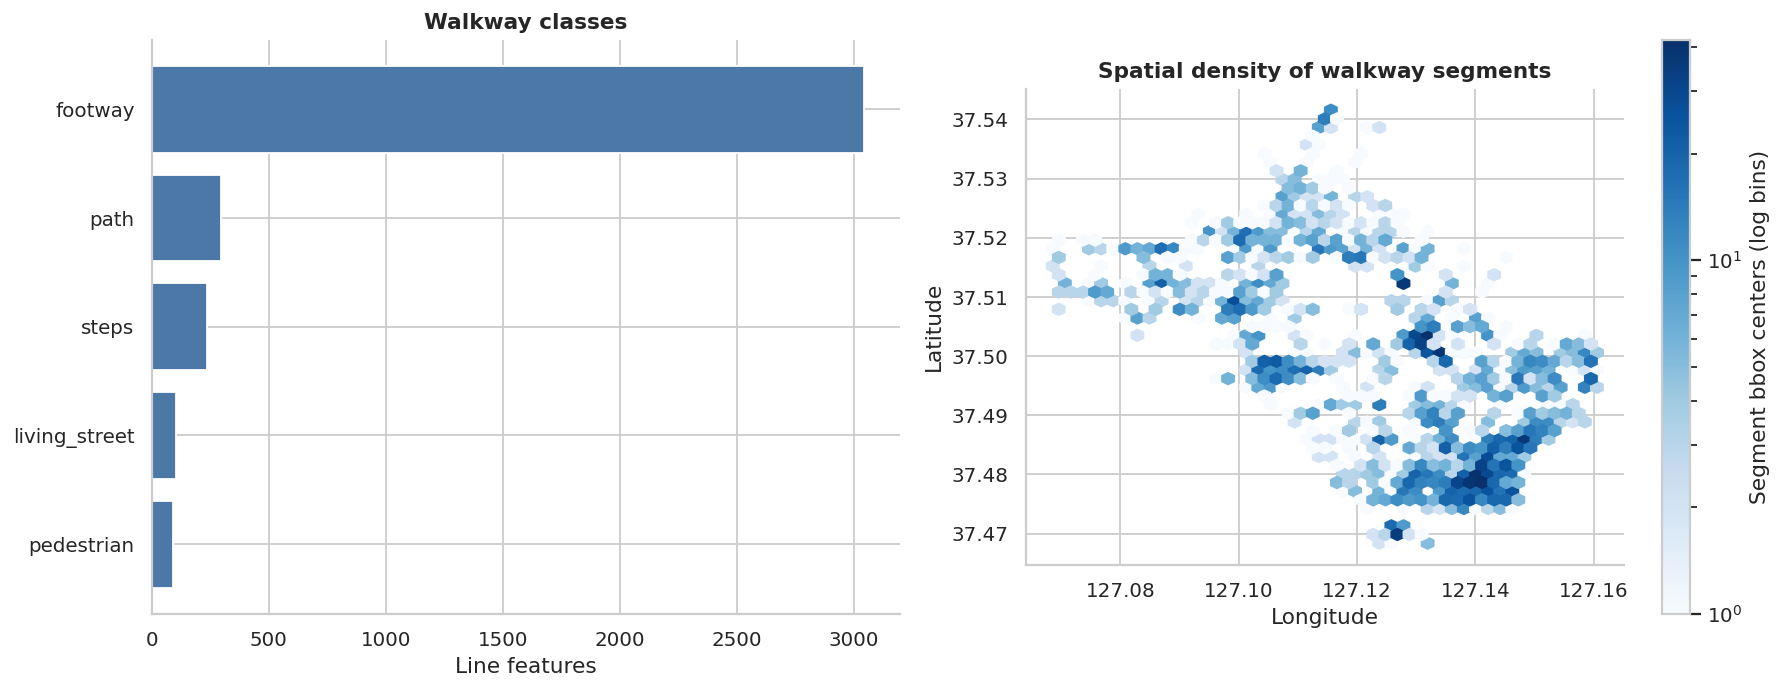

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
top_fclass = walk["fclass"].head(12).sort_values("count")
axes[0].barh(top_fclass["fclass"], top_fclass["count"], color="#4C78A8")
axes[0].set_title("Walkway classes")
axes[0].set_xlabel("Line features")

hb = axes[1].hexbin(walk["centers"]["x"], walk["centers"]["y"], gridsize=45,
                    bins="log", cmap="Blues", mincnt=1)
fig.colorbar(hb, ax=axes[1], label="Segment bbox centers (log bins)")
axes[1].set_title("Spatial density of walkway segments")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

spatial_crs = pd.DataFrame([
    ("Buildings", "Polygon", "EPSG:5179", "projected meters"),
    ("Songpa boundary", "MultiPolygon", "EPSG:5186", "projected meters"),
    ("Songpa walkways", "MultiLineString", "CRS84/WGS84", "longitude/latitude"),
    ("Street trees", "Point columns", "likely WGS84", "longitude/latitude"),
    ("Pavement bbox", "bbox columns", "not declared", "appears scaled integer"),
], columns=["dataset", "geometry", "crs", "coordinate_form"])
display(spatial_crs)


GeoPackage의 `NULL` 결측은 거의 없지만 OSM 계열 속성은 빈 문자열로 저장될 수 있어 두 종류를 함께
확인해야 합니다. 공간 인덱스 중심점 그래프는 선 자체가 아니라 대략적인 분포를 보여줍니다.
가장 중요한 문제는 좌표계입니다. 건물 EPSG:5179, 경계 EPSG:5186, 보행로 WGS84가 서로 다르므로
공간 조인 전에 하나의 CRS로 변환해야 합니다. 좌표 숫자만 보고 바로 겹치면 완전히 다른 위치가 됩니다.


## 7. 잠실 IoT 실측자료 — `jamsil_iot_observations.xlsx`

8개 환경별 시트에 3일 측정값이 가로 방향 블록으로 배치되어 있습니다.
각 날짜는 08:30~17:30, 5분 간격 109행이며 `지면`, `30cm`, `100cm`, `150cm` 값이 있습니다.
머신러닝에는 이 넓은 표를 긴 형식으로 변환해야 합니다.


In [17]:
xls = pd.ExcelFile(paths["iot_excel"])
print("Sheets:", xls.sheet_names)
first_raw = pd.read_excel(paths["iot_excel"], sheet_name=xls.sheet_names[0], header=None)
display(first_raw.iloc[:12, :20])

env_map = {
    "아스팔트": "Asphalt", "흙바닥": "Bare soil", "그늘쉼터": "Shade shelter",
    "버스정류소": "Bus stop", "석촌호수공원": "Lake park", "도심소공원": "Small park",
    "주택밀집지역": "Dense housing", "아파트촌": "Apartment area",
}

long_parts = []
for sheet in xls.sheet_names:
    raw = pd.read_excel(paths["iot_excel"], sheet_name=sheet, header=None)
    env_ko = sheet.split(".", 1)[1]
    for start in [0, 7, 14]:
        date_label = str(raw.iloc[0, start + 2])
        block = raw.iloc[2:111, start:start + 6].copy()
        block.columns = ["hh", "mm", "surface", "30cm", "100cm", "150cm"]
        block["hh"] = pd.to_numeric(block["hh"], errors="coerce").ffill()
        block["mm"] = pd.to_numeric(block["mm"], errors="coerce")
        block["minute_of_day"] = block["hh"] * 60 + block["mm"]
        for sensor in ["surface", "30cm", "100cm", "150cm"]:
            block[sensor] = pd.to_numeric(block[sensor], errors="coerce")
        melted = block.melt(id_vars=["minute_of_day"], value_vars=["surface", "30cm", "100cm", "150cm"],
                            var_name="sensor", value_name="temperature_c")
        melted["environment_ko"] = env_ko
        melted["environment"] = env_map.get(env_ko, env_ko)
        melted["date_label"] = date_label
        long_parts.append(melted)

iot_long = pd.concat(long_parts, ignore_index=True)
display(iot_long.head())
print("Long rows:", len(iot_long), "Duplicate key rows:",
      int(iot_long.duplicated(["environment", "date_label", "minute_of_day", "sensor"]).sum()))


Sheets: ['1.아스팔트', '2.흙바닥', '3.그늘쉼터', '4.버스정류소', '5.석촌호수공원', '6.도심소공원', '7.주택밀집지역', '8.아파트촌']
Long rows: 10464 Duplicate key rows: 0


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,NaN,NaN,7.7일,NaN,NaN,NaN,NaN,NaN,NaN,8.1일,NaN,NaN,NaN,NaN,NaN,NaN,8.3일,NaN,NaN,NaN
1,hh,mm,지면,30cm,100cm,150cm,NaN,hh,mm,지면,30cm,100cm,150cm,NaN,hh,mm,지면,30cm,100cm,150cm
2,8,30,NaN,27,27,27,NaN,8,30,NaN,NaN,27.5,27.5,NaN,8,30,NaN,29.4,29.2,28.9
3,NaN,35,NaN,27,27,26.9,NaN,NaN,35,NaN,28.3,28.2,28.1,NaN,NaN,35,NaN,29.8,29.7,29.4
4,NaN,40,NaN,27,26.9,26.9,NaN,NaN,40,NaN,28.8,28.8,28.7,NaN,NaN,40,NaN,30.4,30.1,29.8
5,NaN,45,NaN,26.9,26.8,26.8,NaN,NaN,45,NaN,29.3,29.2,29.1,NaN,NaN,45,NaN,30.7,30.4,30
6,NaN,50,NaN,27,26.8,26.9,NaN,NaN,50,NaN,29.7,29.6,29.6,NaN,NaN,50,NaN,31.1,30.7,30.3
7,NaN,55,NaN,27.1,26.9,26.9,NaN,NaN,55,NaN,30.1,30,30,NaN,NaN,55,NaN,31.3,30.9,30.5
8,9,0,33.9,27.2,27,26.9,NaN,9,0,40.9,30.5,30.4,30.3,NaN,9,0,41.65,31.4,30.9,30.6
9,NaN,5,NaN,27.3,27.1,27,NaN,NaN,5,NaN,30.8,30.6,30.6,NaN,NaN,5,NaN,31.3,30.8,30.5


,minute_of_day,sensor,temperature_c,environment_ko,environment,date_label
0,510.0,surface,NaN,아스팔트,Asphalt,7.7일
1,515.0,surface,NaN,아스팔트,Asphalt,7.7일
2,520.0,surface,NaN,아스팔트,Asphalt,7.7일
3,525.0,surface,NaN,아스팔트,Asphalt,7.7일
4,530.0,surface,NaN,아스팔트,Asphalt,7.7일


,min,mean,max
environment,,,
Apartment area,91.74,92.05,92.66
Asphalt,91.74,91.74,91.74
Bare soil,91.74,91.74,91.74
Bus stop,91.74,91.74,91.74
Dense housing,91.74,92.05,92.66
Lake park,91.74,92.05,92.66
Shade shelter,91.74,91.74,91.74
Small park,91.74,92.05,92.66


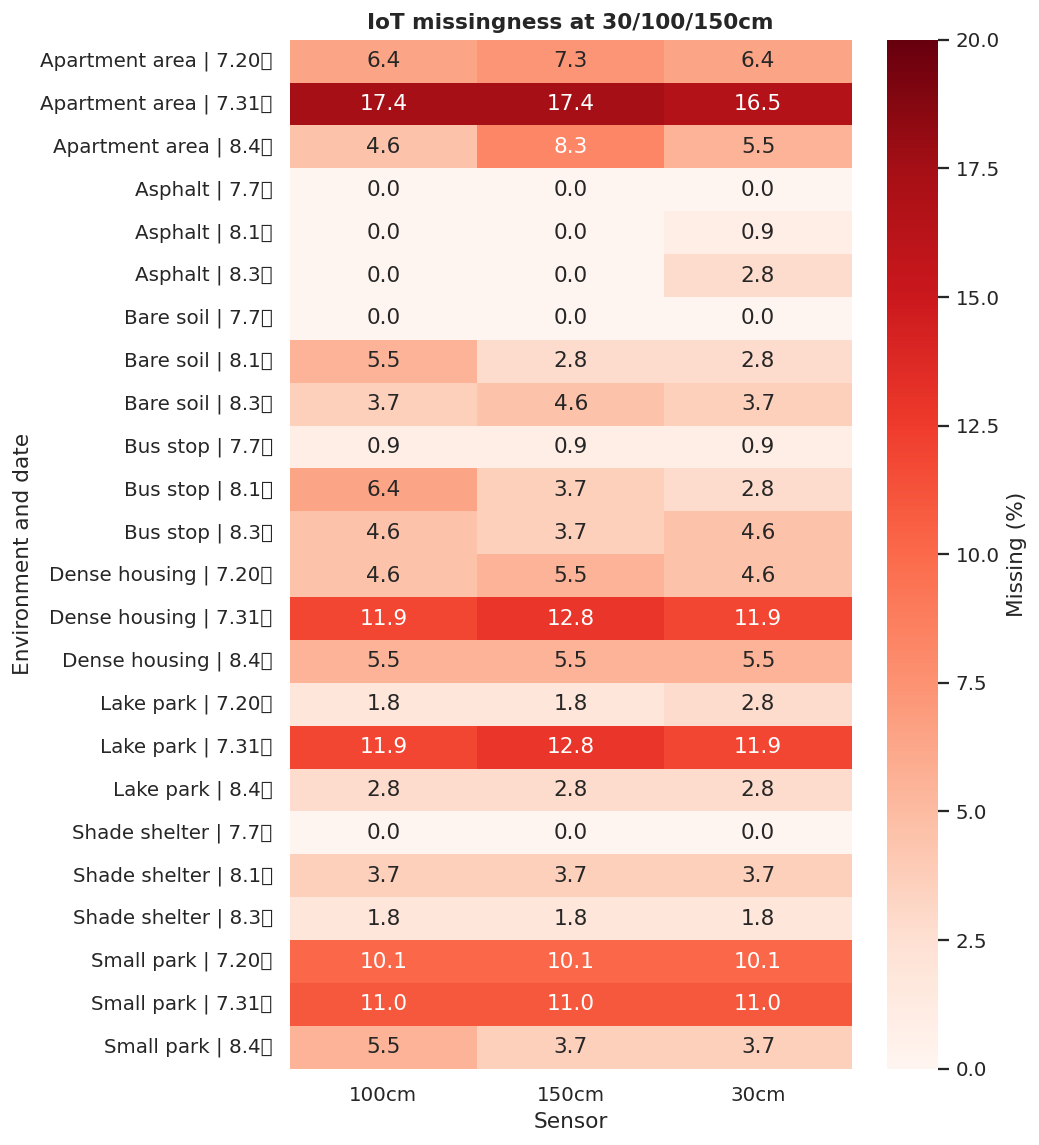

In [18]:
iot_missing = (
    iot_long.assign(missing=iot_long["temperature_c"].isna())
    .groupby(["environment", "date_label", "sensor"])["missing"].mean()
    .mul(100).reset_index()
)
non_surface = iot_missing[iot_missing["sensor"] != "surface"].copy()
non_surface["env_date"] = non_surface["environment"] + " | " + non_surface["date_label"]
miss_pivot = non_surface.pivot(index="env_date", columns="sensor", values="missing")

plt.figure(figsize=(8, 9))
sns.heatmap(miss_pivot, annot=True, fmt=".1f", cmap="Reds", vmin=0, vmax=20,
            cbar_kws={"label": "Missing (%)"})
plt.title("IoT missingness at 30/100/150cm")
plt.xlabel("Sensor")
plt.ylabel("Environment and date")
plt.tight_layout()
plt.show()

surface_missing = iot_missing[iot_missing["sensor"] == "surface"]
display(surface_missing.groupby("environment")["missing"].agg(["min", "mean", "max"]).round(2))


`surface`는 약 91.7~92.7%가 비어 있지만, 이는 지면온도를 매시간 한 번만 기록하고 다른 센서는
5분마다 기록한 설계 때문입니다. 따라서 일반 결측치처럼 선형보간하기 전에 측정 주기를 존중해야 합니다.
반면 30·100·150cm 열의 중간 공백은 실제 누락 후보이며, 7월 31일 일부 환경에서 10~17%로 높습니다.
날짜에 연도가 없고 30/100/150cm가 높이인지 거리인지 메타데이터가 없어 반드시 확인이 필요합니다.


,mean,maximum,count
environment,,,
Shade shelter,28.57,31.1,27
Lake park,29.35,32.0,26
Small park,31.61,42.3,26
Bus stop,32.89,38.5,27
Bare soil,35.81,48.5,27
Apartment area,39.90,46.3,26
Dense housing,40.30,48.6,26
Asphalt,45.21,56.4,27


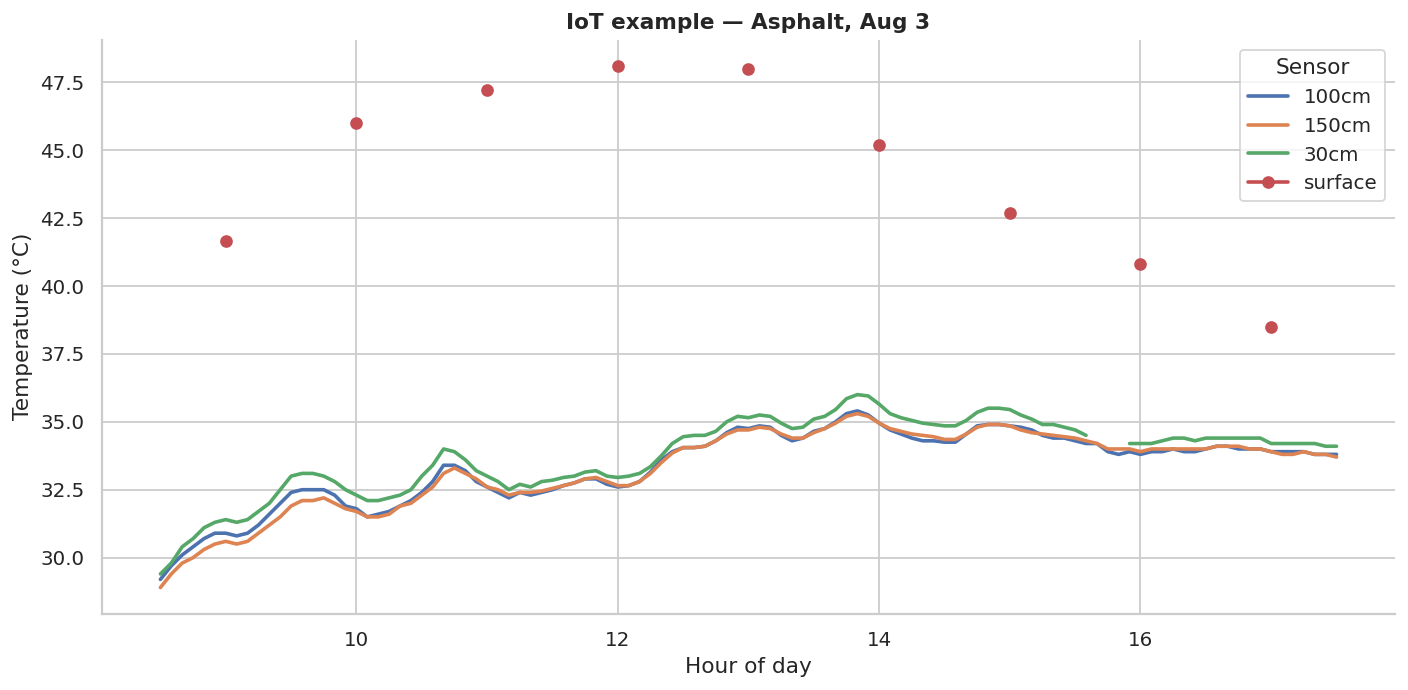

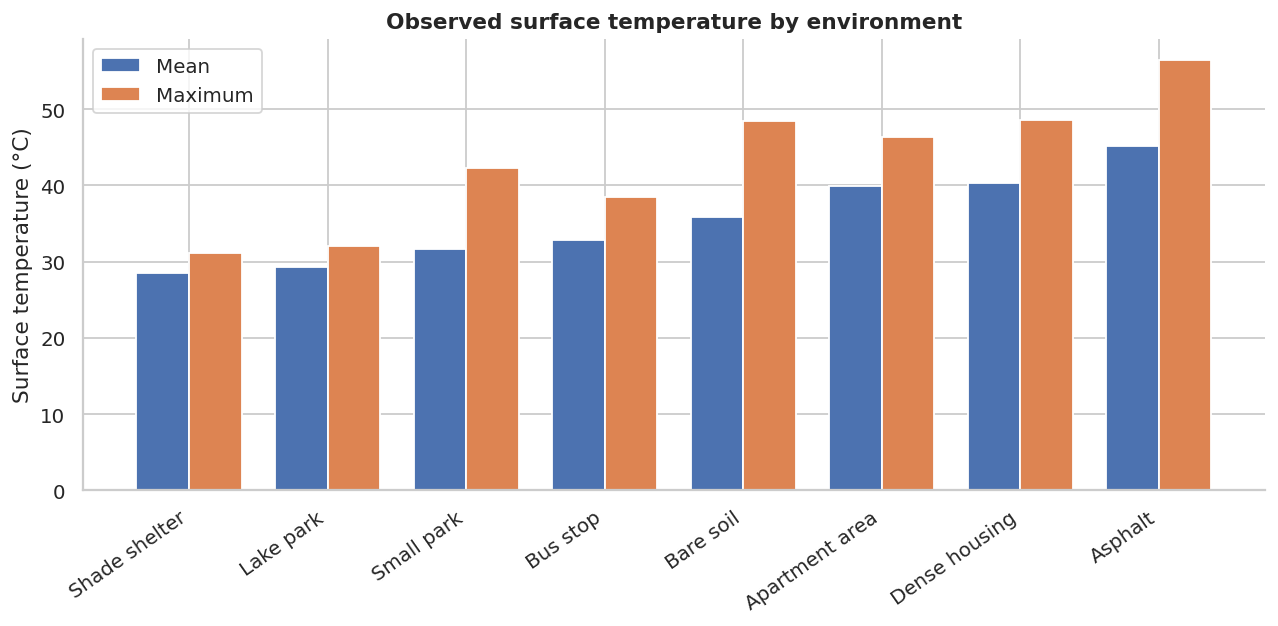

In [19]:
# 대표 시계열: 아스팔트 8.3일
example = iot_long[(iot_long["environment"] == "Asphalt") & (iot_long["date_label"] == "8.3일")]
fig, ax = plt.subplots(figsize=(11, 5.5))
for sensor, group in example.groupby("sensor"):
    style = "o" if sensor == "surface" else None
    ax.plot(group["minute_of_day"] / 60, group["temperature_c"], marker=style,
            linewidth=2, label=sensor)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Temperature (°C)")
ax.set_title("IoT example — Asphalt, Aug 3")
ax.legend(title="Sensor")
plt.tight_layout()
plt.show()

surface_summary = (
    iot_long[iot_long["sensor"] == "surface"]
    .groupby("environment")["temperature_c"]
    .agg(mean="mean", maximum="max", count="count")
    .sort_values("mean")
)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(surface_summary))
width = .38
ax.bar(x - width/2, surface_summary["mean"], width, label="Mean")
ax.bar(x + width/2, surface_summary["maximum"], width, label="Maximum")
ax.set_xticks(x, surface_summary.index, rotation=35, ha="right")
ax.set_ylabel("Surface temperature (°C)")
ax.set_title("Observed surface temperature by environment")
ax.legend()
plt.tight_layout()
plt.show()
display(surface_summary.round(2))


환경별 실측 지면온도 차이가 커서 이 Excel은 매우 중요한 검증자료입니다. 그러나 각 환경의 측정일이
완전히 같지 않고, 기상조건·그늘·정확한 좌표가 붙어 있지 않으므로 막대 높이만으로 재질 효과를 확정할 수 없습니다.
최소한 날짜·시간을 완전한 timestamp로 만들고 같은 시각의 ASOS 기상값과 결합한 뒤 비교해야 합니다.


## 8. 보도 포장재 코드표와 공사자료

`SWM_BASIC_CODE.csv`는 여러 코드의 사전이며, `SWB` 대분류가 포장재질입니다.
`SWM_WKAR_AS.csv` 한 행은 보도면 또는 공사 객체로 보이며 재질 코드, 면적·폭·길이,
공사연도, 행정구 코드, PNU, 공간 bounding box를 포함합니다.


In [20]:
swb_codes = surface_codes[surface_codes["대분류"] == "SWB"].copy()
swb_codes["full_code"] = np.where(swb_codes["코드"].eq("-"), "-", "SWB" + swb_codes["코드"].astype(str).str.zfill(3))
display(swb_codes[["full_code", "코드명", "CDE_DET"]])
print("Code-table missing cells:", int(surface_codes.isna().sum().sum()))

display(pavement.head(5))
pavement_profile = column_profile(pavement)
display(pavement_profile)
print("Duplicate full rows:", int(pavement.duplicated().sum()))


Code-table missing cells: 0
Duplicate full rows: 0


,full_code,코드명,CDE_DET
56,SWB000,해당없음,보도포장재질
58,SWB001,소형고압블록,보도포장재질
62,SWB002,인조화강블록(콘크리트가공블록),보도포장재질
65,SWB003,화강판석,보도포장재질
66,SWB004,점토바닥벽돌,보도포장재질
68,SWB005,아스콘포장,보도포장재질
69,SWB006,고무포장 탄성포장 우레탄포장,보도포장재질
70,SWB007,타일블록 자기질블록,보도포장재질
71,SWB008,시멘트콘크리트포장,보도포장재질
72,SWB999,기타(오나멘트 목재 콘크리트판 등),보도포장재질


,G2_ID,G2_DATASETID,G2_SPATIALTYPE,G2_XMIN,G2_YMIN,G2_XMAX,G2_YMAX,G2_INDEX,G2_SPATIAL,보도면관리번호,FTR_CDE,SEC_IDN,SYS_CHK,RMK,STT_CDE,보도현황관리번호,BDL_ARA,BDL_WID,BDL_LEN,SWB_CODE,VHCLE_PASSWAY_CO,BCCRD_ENNC_CODE,FOM_CODE,CLR_CODE,SIZ_CODE,THK_CODE,PTW_CODE,GU_CDE,RN_NM,RN,BD_MNNM,BD_SLNO,보도면관리번호부번,CNSTRCT_YY,PNU
0,268892,1685,121,21073549,44890677,21074683,44891706,0,NaN,4075,AE001,-,1,-,-,1898,41.62,4.0,5.20,SWB001,-,-,FRM001,CLR001,SIZ003,-,-,740,천호대로,2000008,981,0,1,2003,1174010900104610161
1,268893,1685,121,21076107,44888227,21078408,44889826,0,NaN,4075,AE001,-,1,-,-,1898,116.10,4.0,14.51,SWB001,-,-,FRM001,CLR001,SIZ003,-,-,740,천호대로,2000008,985,0,2,2003,1174010900104580033
2,268894,1685,121,21074468,44890117,21075404,44890937,0,NaN,4075,AE001,-,1,-,-,1898,31.38,4.0,3.92,SWB001,-,-,FRM001,CLR001,SIZ003,-,-,740,천호대로,2000008,983,0,3,2003,1174010900104610161
3,268895,1685,121,21075184,44889423,21076395,44890397,0,NaN,4075,AE001,-,1,-,-,1898,44.08,4.0,5.51,SWB001,-,-,FRM001,CLR001,SIZ003,-,-,740,천호대로,2000008,983,0,4,2003,1174010900104590069
4,268896,1685,121,21072281,44892010,21073117,44892819,0,NaN,4075,AE001,-,1,-,-,1898,27.79,4.0,3.47,SWB001,-,-,FRM001,CLR001,SIZ003,-,-,740,천호대로,2000008,979,0,5,2003,1174010900104610161


,dtype,non_null,missing_n,missing_pct,nunique
G2_ID,int64,55515,0,0.0,55515
G2_DATASETID,int64,55515,0,0.0,1
G2_SPATIALTYPE,int64,55515,0,0.0,2
G2_XMIN,int64,55515,0,0.0,54734
G2_YMIN,int64,55515,0,0.0,54534
G2_XMAX,int64,55515,0,0.0,54758
G2_YMAX,int64,55515,0,0.0,54584
G2_INDEX,int64,55515,0,0.0,1
G2_SPATIAL,float64,0,55515,100.0,1
보도면관리번호,int64,55515,0,0.0,19795


,SWB_CODE,count,material_ko,material,pct
0,SWB001,35873,소형고압블록,Small concrete block,64.62
1,-,7098,보도포장재질,Unknown (-),12.79
2,SWB003,4855,화강판석,Granite slab,8.75
3,SWB004,3227,점토바닥벽돌,Clay paving brick,5.81
4,SWB005,2578,아스콘포장,Asphalt,4.64
5,SWB007,789,타일블록 자기질블록,Tile block,1.42
6,SWB999,640,기타(오나멘트 목재 콘크리트판 등),Other,1.15
7,SWB002,423,인조화강블록(콘크리트가공블록),Artificial granite block,0.76
8,SWB008,32,시멘트콘크리트포장,Cement concrete,0.06


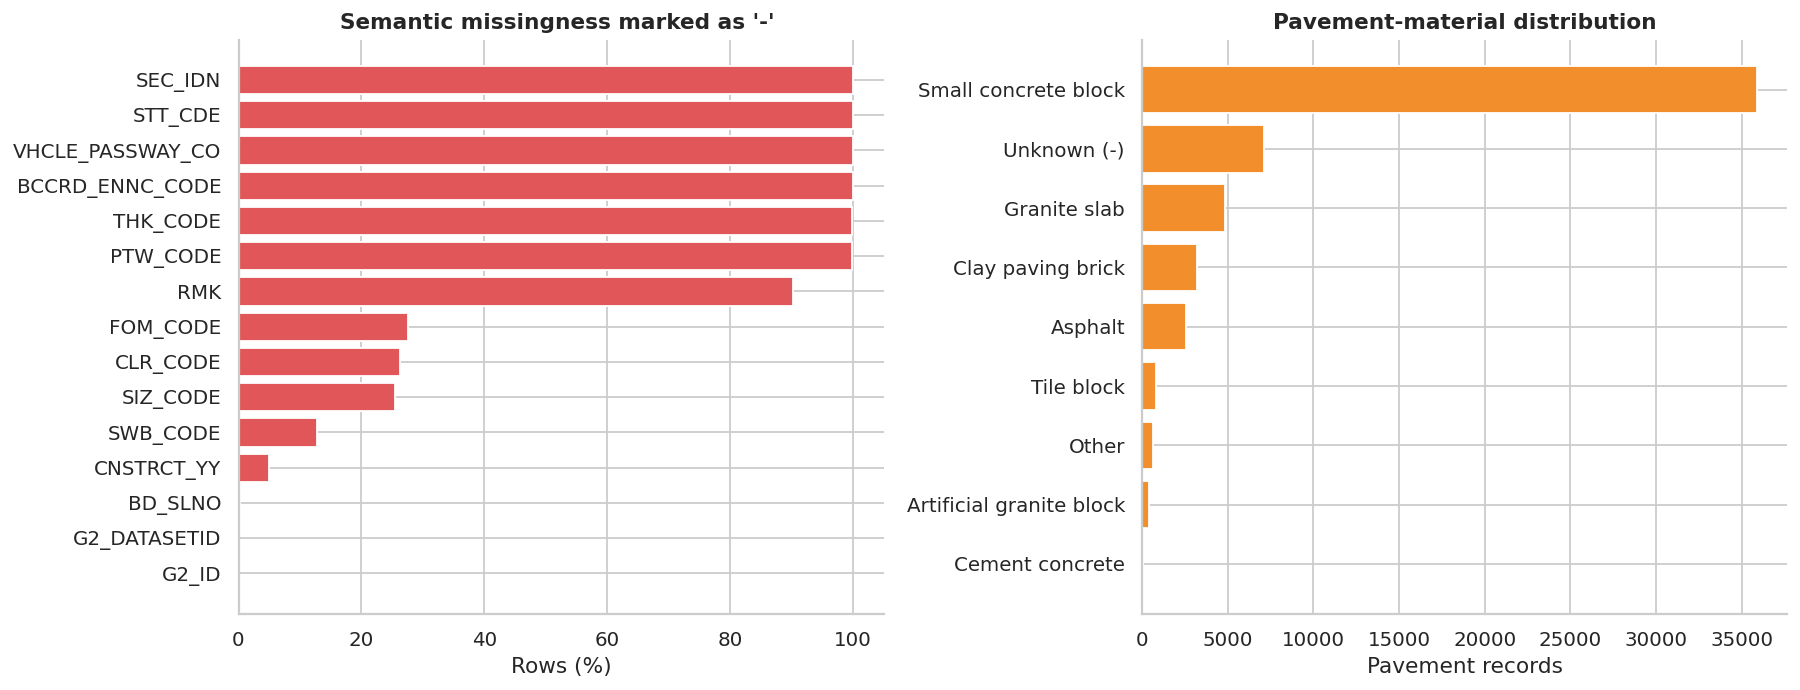

In [21]:
# NaN 외에 '-'를 의미상 결측치로 계산
dash_pct = (pavement.astype(str).eq("-").mean() * 100).sort_values(ascending=False)
semantic_missing = pd.DataFrame({
    "column": dash_pct.index,
    "dash_pct": dash_pct.values,
    "nan_pct": [pavement[c].isna().mean() * 100 for c in dash_pct.index],
}).head(15).sort_values("dash_pct")

material_map_ko = dict(zip(swb_codes["full_code"], swb_codes["코드명"]))
material_map_en = {
    "SWB001": "Small concrete block", "SWB002": "Artificial granite block",
    "SWB003": "Granite slab", "SWB004": "Clay paving brick", "SWB005": "Asphalt",
    "SWB006": "Rubber/urethane", "SWB007": "Tile block", "SWB008": "Cement concrete",
    "SWB999": "Other", "-": "Unknown (-)",
}
material_counts = pavement["SWB_CODE"].value_counts().rename_axis("SWB_CODE").reset_index(name="count")
material_counts["material_ko"] = material_counts["SWB_CODE"].map(material_map_ko)
material_counts["material"] = material_counts["SWB_CODE"].map(material_map_en).fillna(material_counts["SWB_CODE"])
material_counts["pct"] = material_counts["count"] / len(pavement) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].barh(semantic_missing["column"], semantic_missing["dash_pct"], color="#E15759")
axes[0].set_title("Semantic missingness marked as '-' ")
axes[0].set_xlabel("Rows (%)")
ordered = material_counts.sort_values("count")
axes[1].barh(ordered["material"], ordered["count"], color="#F28E2B")
axes[1].set_title("Pavement-material distribution")
axes[1].set_xlabel("Pavement records")
plt.tight_layout()
plt.show()
display(material_counts.round(2))


코드표에는 결측이 없지만 공사자료는 `NaN` 대신 `-`를 많이 사용합니다. `G2_SPATIAL`은 100% NaN이고,
`STT_CDE`, `SEC_IDN`은 모두 `-`입니다. 재질 코드 `-`는 7,098행(12.8%)이며 별도 unknown 범주로
처리해야 합니다. 소형고압블록 `SWB001`이 35,873행으로 가장 많고, 탄성포장 `SWB006`은 현재 자료에 없습니다.


,count,mean,std,min,25%,50%,75%,95%,99%,max
BDL_ARA_num,55515.0,129.80,237.45,1.65,39.2,65.25,124.08,448.77,1100.98,14979.10
BDL_WID_num,55515.0,3.72,1.81,0.60,2.5,3.30,4.50,6.90,10.00,26.00
BDL_LEN_num,55515.0,19.13,38.23,0.31,6.3,9.59,16.99,66.63,162.99,2995.81
CNSTRCT_YY_num,52722.0,2003.45,5.72,1982.00,2000.0,2004.00,2008.00,2011.00,2013.00,2023.00


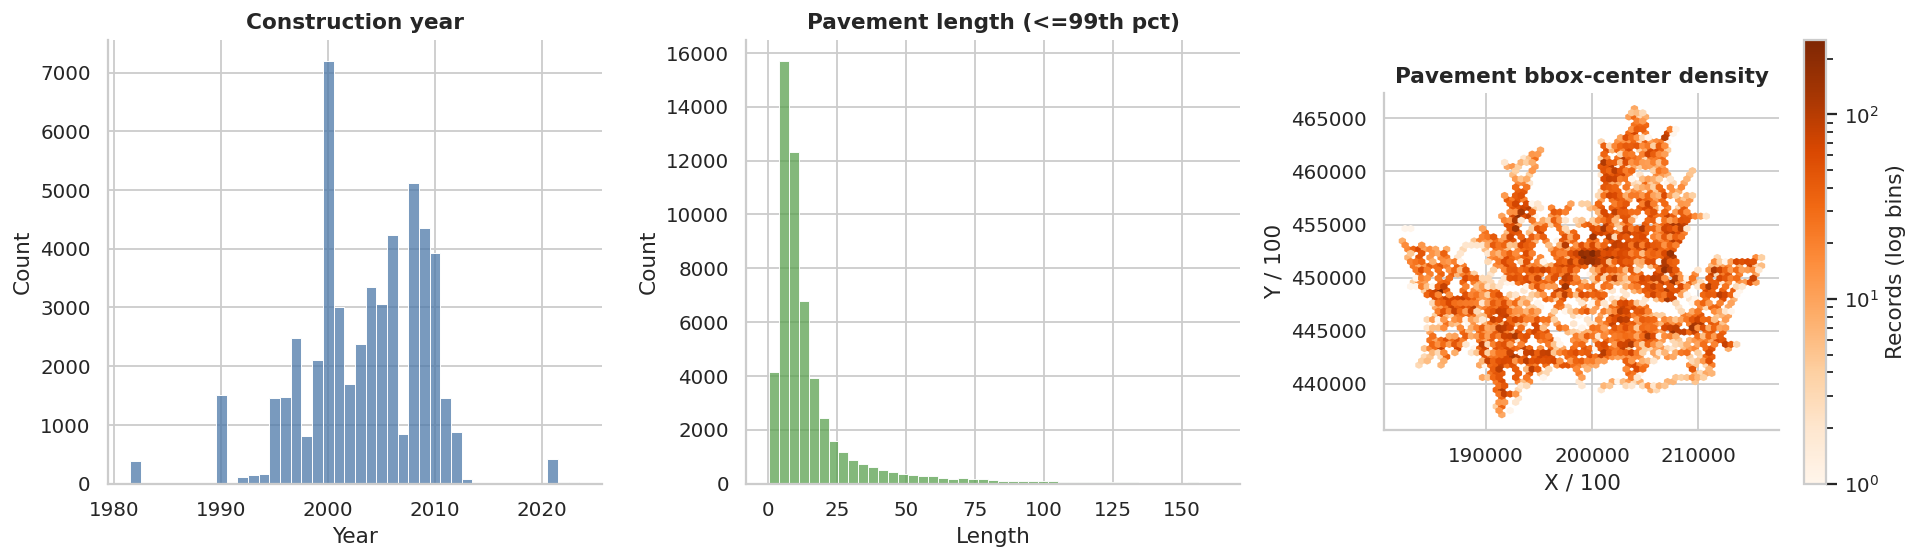

In [22]:
# 공사연도, 크기, 공간 분포
for col in ["CNSTRCT_YY", "BDL_ARA", "BDL_WID", "BDL_LEN", "G2_XMIN", "G2_YMIN", "G2_XMAX", "G2_YMAX"]:
    pavement[col + "_num"] = pd.to_numeric(pavement[col], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(pavement["CNSTRCT_YY_num"], discrete=True, color="#4C78A8", ax=axes[0])
axes[0].set_title("Construction year")
axes[0].set_xlabel("Year")
length_upper = pavement["BDL_LEN_num"].quantile(.99)
sns.histplot(pavement.loc[pavement["BDL_LEN_num"] <= length_upper, "BDL_LEN_num"],
             bins=45, color="#59A14F", ax=axes[1])
axes[1].set_title("Pavement length (<=99th pct)")
axes[1].set_xlabel("Length")

cx = (pavement["G2_XMIN_num"] + pavement["G2_XMAX_num"]) / 2 / 100
cy = (pavement["G2_YMIN_num"] + pavement["G2_YMAX_num"]) / 2 / 100
hb = axes[2].hexbin(cx, cy, gridsize=65, bins="log", cmap="Oranges", mincnt=1)
fig.colorbar(hb, ax=axes[2], label="Records (log bins)")
axes[2].set_title("Pavement bbox-center density")
axes[2].set_xlabel("X / 100")
axes[2].set_ylabel("Y / 100")
axes[2].set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

pavement_stats = pavement[["BDL_ARA_num", "BDL_WID_num", "BDL_LEN_num", "CNSTRCT_YY_num"]].describe(
    percentiles=[.25, .5, .75, .95, .99]
).T.round(2)
display(pavement_stats)


공사연도는 1982~2023년이며 약 5.0%가 `-`입니다. 길이는 중앙값 9.59, 최댓값 2,995.81로
오른쪽 꼬리가 매우 깁니다. 공간 좌표는 2천만·4천5백만대 정수라 그래프에서는 100으로 나누었지만,
정확한 좌표계와 스케일 메타데이터가 없습니다. `G2_SPATIAL` 원 geometry는 비어 있어 bounding box 중심은
대략적 위치일 뿐입니다. CRS 확인 없이 보행로·건물과 공간 조인하면 안 됩니다.


## 9. 원자료 통합 관점의 최종 정리

| 데이터 | 관측 단위 | 핵심 활용 | 가장 큰 품질 문제 |
|---|---|---|---|
| 가로수 | 나무 1그루 | 수관 그늘 | 설명 행 혼입, 0·극단값, 수종명 표기 변형 |
| 건물 Shapefile | 건물 Polygon | 건물 그림자 | 높이 없음, 코드북 필요, EPSG:5179 |
| 건축물대장 | 표제부 | 높이·층수 보완 | 특정 지역 1,736건, 0을 결측으로 검토, 공간 키 불명확 |
| ASOS | 관측소 1시간 | 기상 feature·지면온도 target | 하루 24건, 야간 구조적 공란 |
| 보행로 | 선 1개 | 경로 edge | CRS84, 빈 문자열 속성 |
| 송파 경계 | 구 Polygon 1개 | 분석 범위 | EPSG:5186로 보행로와 다름 |
| IoT 실측 | 환경·날짜·시간·센서 | 현장 온도 target·검증 | 날짜 연도·좌표·센서 의미 없음, 측정주기 다름 |
| 포장재 코드 | 코드 1개 | 코드 해석 | 코드 자체는 양호 |
| 포장재 공사 | 보도면/공사 객체 | 노면 재질 | `-` 의미상 결측, geometry 없음, CRS·스케일 불명확 |

### 중요한 결론

이전 정제 데이터와 달리 원자료에는 실제 온도 target 후보가 있습니다.

- ASOS `지면온도(°C)`: 24시간 완전 관측
- IoT `surface`: 8개 환경 × 3일의 시간별 관측

따라서 지도학습 방향은 가능성이 생겼지만, 지금 바로 모든 공간 feature와 결합할 수는 없습니다.
IoT의 좌표·완전한 날짜, 포장재 공간 좌표계, 건물대장과 Polygon 결합 키가 없기 때문입니다.

### 권장 정제 순서

1. 가로수 영문 설명 행 제거, 숫자형 변환, 0·극단값 규칙 정의, 수종명 표준화
2. ASOS의 구조적 공란과 실제 결측을 분리하고 여러 날짜 확보
3. IoT Excel을 긴 형식으로 변환하되 surface의 시간별 측정주기를 보존
4. 건물·경계·보행로를 공통 CRS로 변환하고 송파구로 clip
5. 포장재 좌표 스케일·CRS를 확인한 뒤 `SWB_CODE='-'`를 unknown으로 처리
6. IoT 좌표·날짜를 확보하여 같은 시각의 기상·그늘·포장재와 결합
7. 날짜 단위 검증 세트를 둔 지도학습 모델 구축

이 단계에서는 평균 대체나 일괄 보간보다 **결측의 의미와 결합 키를 확인하는 작업**이 우선입니다.
